---
# Part 1 >> Preprocessing


In [1]:
import os

for dirname, _, filenames in os.walk('/kaggle/input'):
    print(dirname)

/kaggle/input
/kaggle/input/datasets
/kaggle/input/datasets/masoudnickparvar
/kaggle/input/datasets/masoudnickparvar/brain-tumor-mri-dataset
/kaggle/input/datasets/masoudnickparvar/brain-tumor-mri-dataset/Training
/kaggle/input/datasets/masoudnickparvar/brain-tumor-mri-dataset/Training/pituitary
/kaggle/input/datasets/masoudnickparvar/brain-tumor-mri-dataset/Training/notumor
/kaggle/input/datasets/masoudnickparvar/brain-tumor-mri-dataset/Training/meningioma
/kaggle/input/datasets/masoudnickparvar/brain-tumor-mri-dataset/Training/glioma
/kaggle/input/datasets/masoudnickparvar/brain-tumor-mri-dataset/Testing
/kaggle/input/datasets/masoudnickparvar/brain-tumor-mri-dataset/Testing/pituitary
/kaggle/input/datasets/masoudnickparvar/brain-tumor-mri-dataset/Testing/notumor
/kaggle/input/datasets/masoudnickparvar/brain-tumor-mri-dataset/Testing/meningioma
/kaggle/input/datasets/masoudnickparvar/brain-tumor-mri-dataset/Testing/glioma


### Imports & Configuration

In [2]:
import os
import random
import warnings
import cv2
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from collections import Counter

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torchvision import transforms
from PIL import Image
from sklearn.model_selection import train_test_split
from tqdm import tqdm
import albumentations as A
from albumentations.pytorch import ToTensorV2

warnings.filterwarnings('ignore')

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark     = False

BASE_DIR  = "/kaggle/input/datasets/masoudnickparvar/brain-tumor-mri-dataset"
TRAIN_DIR = f"{BASE_DIR}/Training"
TEST_DIR  = f"{BASE_DIR}/Testing"

IMG_SIZE    = 224
VAL_SPLIT   = 0.15
BATCH_SIZE  = 32
NUM_WORKERS = 2  

VALID_EXTENSIONS = (".jpg", ".jpeg", ".png", ".tif", ".tiff")

BINARY_MODE        = True
TUMOR_LABEL        = 1
NO_TUMOR_LABEL     = 0
NO_TUMOR_CLASS     = "notumor"

CLASSES = sorted([
    d for d in os.listdir(TRAIN_DIR)
    if os.path.isdir(os.path.join(TRAIN_DIR, d)) and not d.startswith('.')
])
NUM_CLASSES  = len(CLASSES)
CLASS_TO_IDX = {cls: idx for idx, cls in enumerate(CLASSES)}   

BINARY_LABEL_MAP = {
    cls: (NO_TUMOR_LABEL if cls == NO_TUMOR_CLASS else TUMOR_LABEL)
    for cls in CLASSES
}
BINARY_CLASS_NAMES = ["No Tumor", "Tumor"]   


POS_WEIGHT: float | None = None           
EFFECTIVE_POS_WEIGHT: float | None = None  

print(f"4-class map     : {CLASS_TO_IDX}")
print(f"Binary label map: {BINARY_LABEL_MAP}")
print(f"Device          : {'CUDA' if torch.cuda.is_available() else 'CPU'}")



4-class map     : {'glioma': 0, 'meningioma': 1, 'notumor': 2, 'pituitary': 3}
Binary label map: {'glioma': 1, 'meningioma': 1, 'notumor': 0, 'pituitary': 1}
Device          : CUDA


### Brain Crop & CLAHE

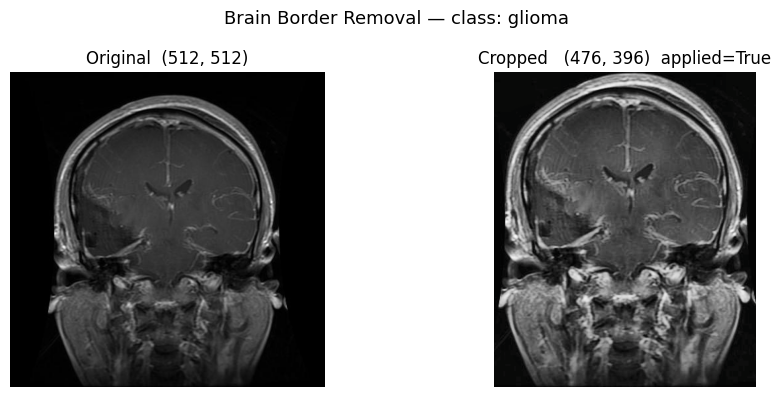

In [3]:
CROP_THRESHOLD = 10   
MIN_CROP_RATIO = 0.10 


def crop_brain_region(image: np.ndarray,
                      threshold: int = CROP_THRESHOLD,
                      min_crop_ratio: float = MIN_CROP_RATIO):
  
    original_area = image.shape[0] * image.shape[1]

    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY) if len(image.shape) == 3 else image.copy()

    _, thresh = cv2.threshold(gray, threshold, 255, cv2.THRESH_BINARY)

   
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5, 5))
    thresh = cv2.morphologyEx(thresh, cv2.MORPH_CLOSE, kernel)

    coords = cv2.findNonZero(thresh)
    if coords is None:
        return image, False

    x, y, w, h = cv2.boundingRect(coords)
    crop_area   = w * h

    if crop_area < (min_crop_ratio * original_area):
        return image, False 

    return image[y:y + h, x:x + w], True


def load_and_crop(image_path: str):
    img = cv2.imread(image_path)
    if img is None:
        raise FileNotFoundError(f"Cannot read: {image_path}")
    img, applied = crop_brain_region(img)

    
    lab   = cv2.cvtColor(img, cv2.COLOR_BGR2LAB)
    l, a, b = cv2.split(lab)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    l     = clahe.apply(l)
    img   = cv2.cvtColor(cv2.merge([l, a, b]), cv2.COLOR_LAB2BGR)

    
    return cv2.cvtColor(img, cv2.COLOR_BGR2RGB), applied


sample_class    = CLASSES[0]
sample_img_path = os.path.join(TRAIN_DIR, sample_class,
                               sorted(os.listdir(os.path.join(TRAIN_DIR, sample_class)))[0])

raw_bgr     = cv2.imread(sample_img_path)
raw_rgb     = cv2.cvtColor(raw_bgr, cv2.COLOR_BGR2RGB)
cropped_rgb, applied = load_and_crop(sample_img_path)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].imshow(raw_rgb);     axes[0].set_title(f"Original  {raw_rgb.shape[:2]}");      axes[0].axis("off")
axes[1].imshow(cropped_rgb); axes[1].set_title(f"Cropped   {cropped_rgb.shape[:2]}  applied={applied}"); axes[1].axis("off")
plt.suptitle(f"Brain Border Removal — class: {sample_class}", fontsize=13)
plt.tight_layout(); plt.show()

### Dataset Validation

Validating 5600 images in '/kaggle/input/datasets/masoudnickparvar/brain-tumor-mri-dataset/Training' …


Validating: 100%|██████████| 5600/5600 [01:06<00:00, 84.69it/s] 


  Total scanned   : 5600
  Corrupt/blank   : 0
  Crop guard hits : 0  (original returned)
  Avg crop removal: 19.0%
  Max crop removal: 68.5%


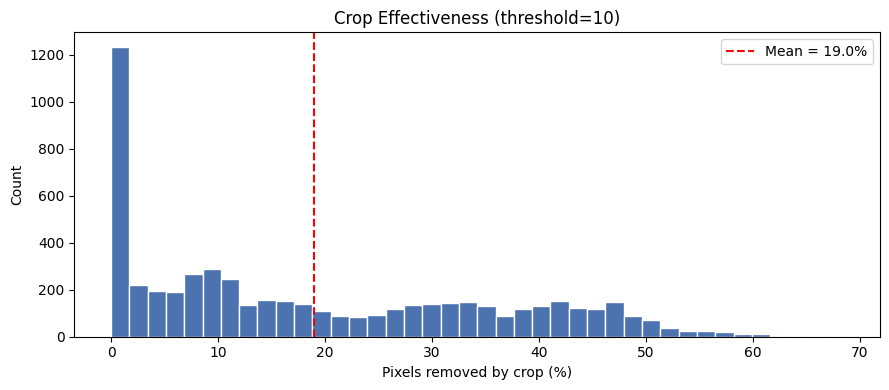

In [4]:
def validate_dataset(directory: str, classes: list,
                     threshold: int = CROP_THRESHOLD) -> tuple:
  
    valid_paths, bad_paths, crop_reductions = [], [], []

    all_files = [
        os.path.join(directory, cls, fname)
        for cls in sorted(classes)
        for fname in sorted(os.listdir(os.path.join(directory, cls)))
        if fname.lower().endswith(VALID_EXTENSIONS)
    ]

    print(f"Validating {len(all_files)} images in '{directory}' …")
    failed_crops = 0

    for path in tqdm(all_files, desc="Validating"):
        img = cv2.imread(path)

        if img is None:
            bad_paths.append(path); continue

        gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
        if gray.std() < 1.0:
            bad_paths.append(path); continue

        original_area = img.shape[0] * img.shape[1]
        cropped, applied = crop_brain_region(img, threshold=threshold)

        if not applied:
            failed_crops += 1
        else:
            crop_area     = cropped.shape[0] * cropped.shape[1]
            crop_reductions.append((1 - crop_area / original_area) * 100)

        valid_paths.append(path)

    print(f"  Total scanned   : {len(all_files)}")
    print(f"  Corrupt/blank   : {len(bad_paths)}")
    print(f"  Crop guard hits : {failed_crops}  (original returned)")
    if crop_reductions:
        print(f"  Avg crop removal: {np.mean(crop_reductions):.1f}%")
        print(f"  Max crop removal: {np.max(crop_reductions):.1f}%")
    return valid_paths, crop_reductions


valid_train_paths, crop_reductions = validate_dataset(TRAIN_DIR, CLASSES)

if crop_reductions:
    plt.figure(figsize=(9, 4))
    plt.hist(crop_reductions, bins=40, color="#4C72B0", edgecolor="white")
    plt.xlabel("Pixels removed by crop (%)"); plt.ylabel("Count")
    plt.title(f"Crop Effectiveness (threshold={CROP_THRESHOLD})")
    plt.axvline(np.mean(crop_reductions), color="red", linestyle="--",
                label=f"Mean = {np.mean(crop_reductions):.1f}%")
    plt.legend(); plt.tight_layout(); plt.show()

### Class Distribution

Training set class counts:
           glioma: 1400  → binary label = 1
       meningioma: 1400  → binary label = 1
          notumor: 1400  → binary label = 0
        pituitary: 1400  → binary label = 1

Imbalance ratio (4-class) : 1.00×  (mild)
Total training  : 5600
Total testing   : 1600

Binary training : No Tumor=1400  Tumor=4200
Binary testing  : No Tumor=400   Tumor=1200
Binary imbalance: 3.00×  (Tumor:NoTumor) — WeightedSampler active


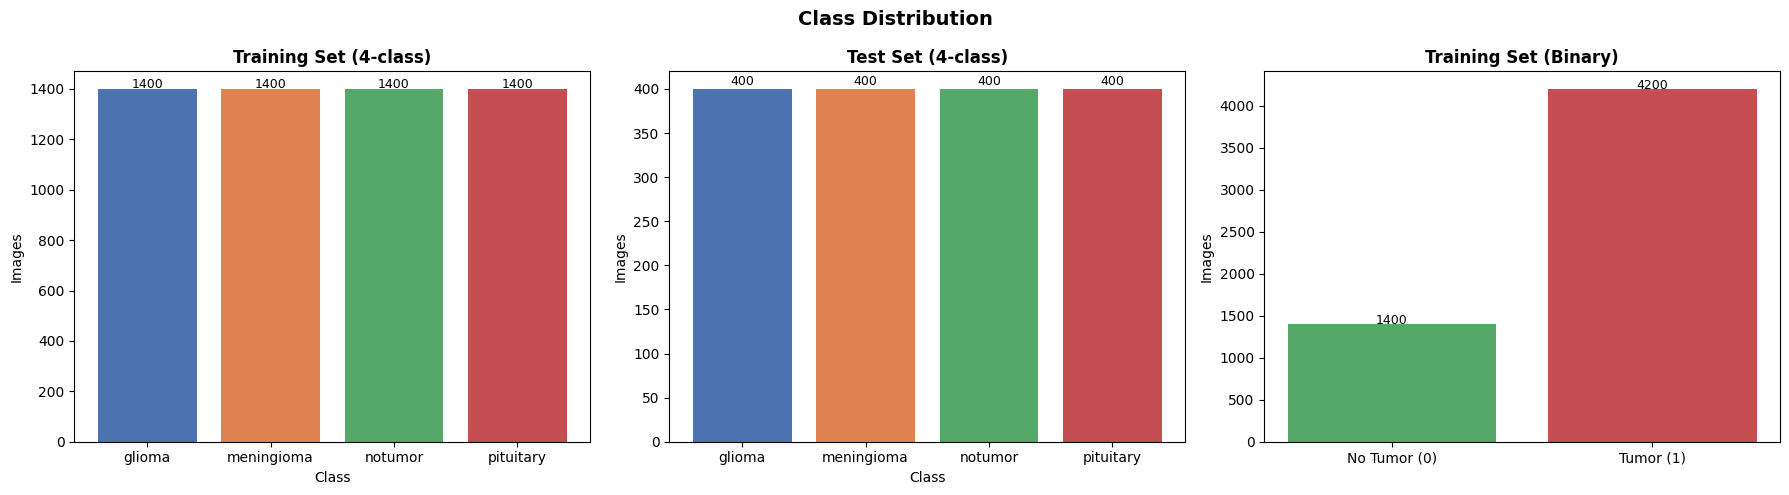

In [5]:
def count_samples(directory: str, classes: list) -> dict:
    return {
        cls: len([
            f for f in sorted(os.listdir(os.path.join(directory, cls)))
            if f.lower().endswith(VALID_EXTENSIONS)
        ])
        for cls in classes
    }

train_counts = count_samples(TRAIN_DIR, CLASSES)
test_counts  = count_samples(TEST_DIR,  CLASSES)

print("Training set class counts:")
for cls, cnt in train_counts.items():
    print(f"  {cls:>15s}: {cnt}  → binary label = {BINARY_LABEL_MAP[cls]}")

max_count = max(train_counts.values())
min_count = min(train_counts.values())
imbalance_ratio = max_count / min_count
severity = "moderate — WeightedSampler recommended" if imbalance_ratio > 1.5 else "mild"
print(f"\nImbalance ratio (4-class) : {imbalance_ratio:.2f}×  ({severity})")
print(f"Total training  : {sum(train_counts.values())}")
print(f"Total testing   : {sum(test_counts.values())}")

# Binary counts
binary_train = Counter()
for cls, cnt in train_counts.items():
    binary_train[BINARY_LABEL_MAP[cls]] += cnt
binary_test = Counter()
for cls, cnt in test_counts.items():
    binary_test[BINARY_LABEL_MAP[cls]] += cnt

print(f"\nBinary training : No Tumor={binary_train[0]}  Tumor={binary_train[1]}")
print(f"Binary testing  : No Tumor={binary_test[0]}   Tumor={binary_test[1]}")
bin_ratio = binary_train[1] / binary_train[0]
print(f"Binary imbalance: {bin_ratio:.2f}×  (Tumor:NoTumor) — WeightedSampler active")

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
palette4 = ["#4C72B0", "#DD8452", "#55A868", "#C44E52"]
palette2 = ["#55A868", "#C44E52"]

for ax, counts, title, pal in zip(
    axes[:2], [train_counts, test_counts],
    ["Training Set (4-class)", "Test Set (4-class)"], [palette4, palette4]
):
    bars = ax.bar(counts.keys(), counts.values(), color=pal)
    ax.set_title(title, fontsize=12, fontweight="bold")
    ax.set_ylabel("Images"); ax.set_xlabel("Class")
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height()+5,
                str(int(bar.get_height())), ha="center", fontsize=9)

# Binary bar
ax = axes[2]
labels_bin = ["No Tumor (0)", "Tumor (1)"]
vals_bin   = [binary_train[0], binary_train[1]]
bars = ax.bar(labels_bin, vals_bin, color=palette2)
ax.set_title("Training Set (Binary)", fontsize=12, fontweight="bold")
ax.set_ylabel("Images")
for bar in bars:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height()+5,
            str(int(bar.get_height())), ha="center", fontsize=9)

plt.suptitle("Class Distribution", fontsize=14, fontweight="bold")
plt.tight_layout(); plt.show()


### File Lists & Train/Val/Test Split

In [6]:
def build_file_list(directory: str, classes: list, class_to_idx: dict,
                    valid_paths_set: set = None,
                    binary: bool = BINARY_MODE) -> tuple:
   
    paths, labels = [], []
    for cls in sorted(classes):
        cls_dir = os.path.join(directory, cls)
        for fname in sorted(os.listdir(cls_dir)):
            if fname.lower().endswith(VALID_EXTENSIONS):
                full_path = os.path.join(cls_dir, fname)
                if valid_paths_set and full_path not in valid_paths_set:
                    continue
                paths.append(full_path)
                labels.append(
                    BINARY_LABEL_MAP[cls] if binary else class_to_idx[cls]
                )
    return paths, labels


AR_WARN_LOW  = 0.5   
AR_WARN_HIGH = 2.0   

def audit_aspect_ratios(directory: str, classes: list,
                        warn_low: float = AR_WARN_LOW,
                        warn_high: float = AR_WARN_HIGH) -> list:
    flagged = []
    all_ars = []
    for cls in sorted(classes):
        cls_dir = os.path.join(directory, cls)
        for fname in sorted(os.listdir(cls_dir)):
            if not fname.lower().endswith(VALID_EXTENSIONS):
                continue
            img = cv2.imread(os.path.join(cls_dir, fname))
            if img is None:
                continue
            h, w = img.shape[:2]
            ar = w / h
            all_ars.append(ar)
            if ar < warn_low or ar > warn_high:
                flagged.append((os.path.join(cls_dir, fname), ar))
    return flagged, all_ars

print("Running aspect-ratio audit on Training set")
flagged_ars, all_ars = audit_aspect_ratios(TRAIN_DIR, CLASSES)
print(f"  Images audited  : {len(all_ars)}")
print(f"  Mean AR (w/h)   : {np.mean(all_ars):.3f}")
print(f"  Min AR          : {np.min(all_ars):.3f}")
print(f"  Max AR          : {np.max(all_ars):.3f}")
print(f"  Flagged (outside [{AR_WARN_LOW}, {AR_WARN_HIGH}]) : {len(flagged_ars)}")
if flagged_ars:
    print("  Sample flagged paths:")
    for p, ar in flagged_ars[:5]:
        print(f"    AR={ar:.2f}  {p}")
else:
    print(" No extreme aspect ratios detected .")

valid_train_set = set(valid_train_paths)
all_train_paths, all_train_labels = build_file_list(
    TRAIN_DIR, CLASSES, CLASS_TO_IDX, valid_paths_set=valid_train_set
)

valid_test_paths, _ = validate_dataset(TEST_DIR, CLASSES)
valid_test_set = set(valid_test_paths)
test_paths, test_labels = build_file_list(
    TEST_DIR, CLASSES, CLASS_TO_IDX, valid_paths_set=valid_test_set
)

train_paths, val_paths, train_labels, val_labels = train_test_split(
    all_train_paths, all_train_labels,
    test_size=VAL_SPLIT,
    random_state=SEED,
    stratify=all_train_labels   # preserves binary class ratios
)

print(f"\nTrain  : {len(train_paths)} samples")
print(f"Val    : {len(val_paths)} samples")
print(f"Test   : {len(test_paths)} samples")

print(f"\nBinary label distribution (train)  : {Counter(train_labels)}")
print(f"Binary label distribution (val)    : {Counter(val_labels)}")
print(f"Binary label distribution (test)   : {Counter(test_labels)}")

assert len(set(train_paths) & set(val_paths))  == 0, "LEAKAGE: train ∩ val"
assert len(set(train_paths) & set(test_paths)) == 0, "LEAKAGE: train ∩ test"
assert len(set(val_paths)   & set(test_paths)) == 0, "LEAKAGE: val  ∩ test"


Running aspect-ratio audit on Training set
  Images audited  : 5600
  Mean AR (w/h)   : 0.988
  Min AR          : 0.645
  Max AR          : 1.786
  Flagged (outside [0.5, 2.0]) : 0
 No extreme aspect ratios detected .
Validating 1600 images in '/kaggle/input/datasets/masoudnickparvar/brain-tumor-mri-dataset/Testing' …


Validating: 100%|██████████| 1600/1600 [00:17<00:00, 91.93it/s] 


  Total scanned   : 1600
  Corrupt/blank   : 0
  Crop guard hits : 0  (original returned)
  Avg crop removal: 18.2%
  Max crop removal: 66.2%

Train  : 4760 samples
Val    : 840 samples
Test   : 1600 samples

Binary label distribution (train)  : Counter({1: 3570, 0: 1190})
Binary label distribution (val)    : Counter({1: 630, 0: 210})
Binary label distribution (test)   : Counter({1: 1200, 0: 400})


### Normalization Statistics

In [7]:
def compute_normalization_stats(paths: list, img_size: int = IMG_SIZE) -> tuple:
   
    channel_sums    = np.zeros(3, dtype=np.float64)
    channel_sq_sums = np.zeros(3, dtype=np.float64)
    pixel_count     = 0

    for path in tqdm(paths, desc="Stats (train only)"):
        img, _ = load_and_crop(path)                    # crop first
        img    = cv2.resize(img, (img_size, img_size))  # then resize
        img    = img.astype(np.float64) / 255.0

        channel_sums    += img.sum(axis=(0, 1))
        channel_sq_sums += (img ** 2).sum(axis=(0, 1))
        pixel_count     += img_size * img_size

    mean = channel_sums / pixel_count
    std  = np.sqrt(np.clip(channel_sq_sums / pixel_count - mean ** 2, 1e-8, None))

    return mean.tolist(), std.tolist()


DATASET_MEAN, DATASET_STD = compute_normalization_stats(train_paths)

print("\nNormalization stats:")
print(f"  Mean : {[round(m, 4) for m in DATASET_MEAN]}")
print(f"  Std  : {[round(s, 4) for s in DATASET_STD]}")

Stats (train only): 100%|██████████| 4760/4760 [00:53<00:00, 89.29it/s] 


Normalization stats:
  Mean : [0.2992, 0.2994, 0.2993]
  Std  : [0.2353, 0.2351, 0.2352]


### Augmentation Pipeline & MixUp

In [8]:

_albu_train = A.Compose([
    A.GridDistortion(num_steps=5, distort_limit=0.3, p=0.35),
    A.ElasticTransform(alpha=1.0, sigma=50, p=0.35),
])

def apply_albu(image: np.ndarray) -> np.ndarray:
    """Apply albumentations transforms; input/output are HWC uint8 RGB arrays."""
    return _albu_train(image=image)["image"]


train_transforms = transforms.Compose([
    transforms.Lambda(apply_albu),

    transforms.ToPILImage(),

    transforms.RandomHorizontalFlip(p=0.5),

    transforms.RandomVerticalFlip(p=0.3),

    transforms.RandomRotation(degrees=15),

    transforms.RandomResizedCrop(
        size=IMG_SIZE,
        scale=(0.85, 1.0),
        ratio=(0.9, 1.1),
    ),

    transforms.ColorJitter(
        brightness=0.2, contrast=0.2,
        saturation=0.1, hue=0.0,
    ),

    transforms.RandomApply(
        [transforms.GaussianBlur(kernel_size=3, sigma=(0.1, 1.0))], p=0.5
    ),

    transforms.ToTensor(),
    transforms.Normalize(mean=DATASET_MEAN, std=DATASET_STD),

    transforms.RandomErasing(p=0.3, scale=(0.02, 0.15), ratio=(0.3, 3.3), value=0),
])

eval_transforms = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=DATASET_MEAN, std=DATASET_STD),
])



MIXUP_ALPHA = 0.3  

def mixup_batch(images: torch.Tensor, labels: torch.Tensor,
                alpha: float = MIXUP_ALPHA):
   
    if alpha <= 0:
        return images, labels, labels, 1.0
    lam   = float(np.random.beta(alpha, alpha))
    idx   = torch.randperm(images.size(0))
    mixed = lam * images + (1 - lam) * images[idx]
    return mixed, labels, labels[idx], lam

print("Train transforms:")
for t in train_transforms.transforms:
    print(f"  {t}")
print(f"\nNorm mean : {[round(m,4) for m in DATASET_MEAN]}")
print(f"Norm std  : {[round(s,4) for s in DATASET_STD]}")
print()


Train transforms:
  Lambda()
  ToPILImage()
  RandomHorizontalFlip(p=0.5)
  RandomVerticalFlip(p=0.3)
  RandomRotation(degrees=[-15.0, 15.0], interpolation=nearest, expand=False, fill=0)
  RandomResizedCrop(size=(224, 224), scale=(0.85, 1.0), ratio=(0.9, 1.1), interpolation=bilinear, antialias=True)
  ColorJitter(brightness=(0.8, 1.2), contrast=(0.8, 1.2), saturation=(0.9, 1.1), hue=None)
  RandomApply(
    p=0.5
    GaussianBlur(kernel_size=(3, 3), sigma=(0.1, 1.0))
)
  ToTensor()
  Normalize(mean=[0.2991803687402325, 0.2994408581283585, 0.29926511447873844], std=[0.23533879253551385, 0.23512734931454665, 0.23524028388030652])
  RandomErasing(p=0.3, scale=(0.02, 0.15), ratio=(0.3, 3.3), value=0, inplace=False)

Norm mean : [0.2992, 0.2994, 0.2993]
Norm std  : [0.2353, 0.2351, 0.2352]



### Augmentation Preview

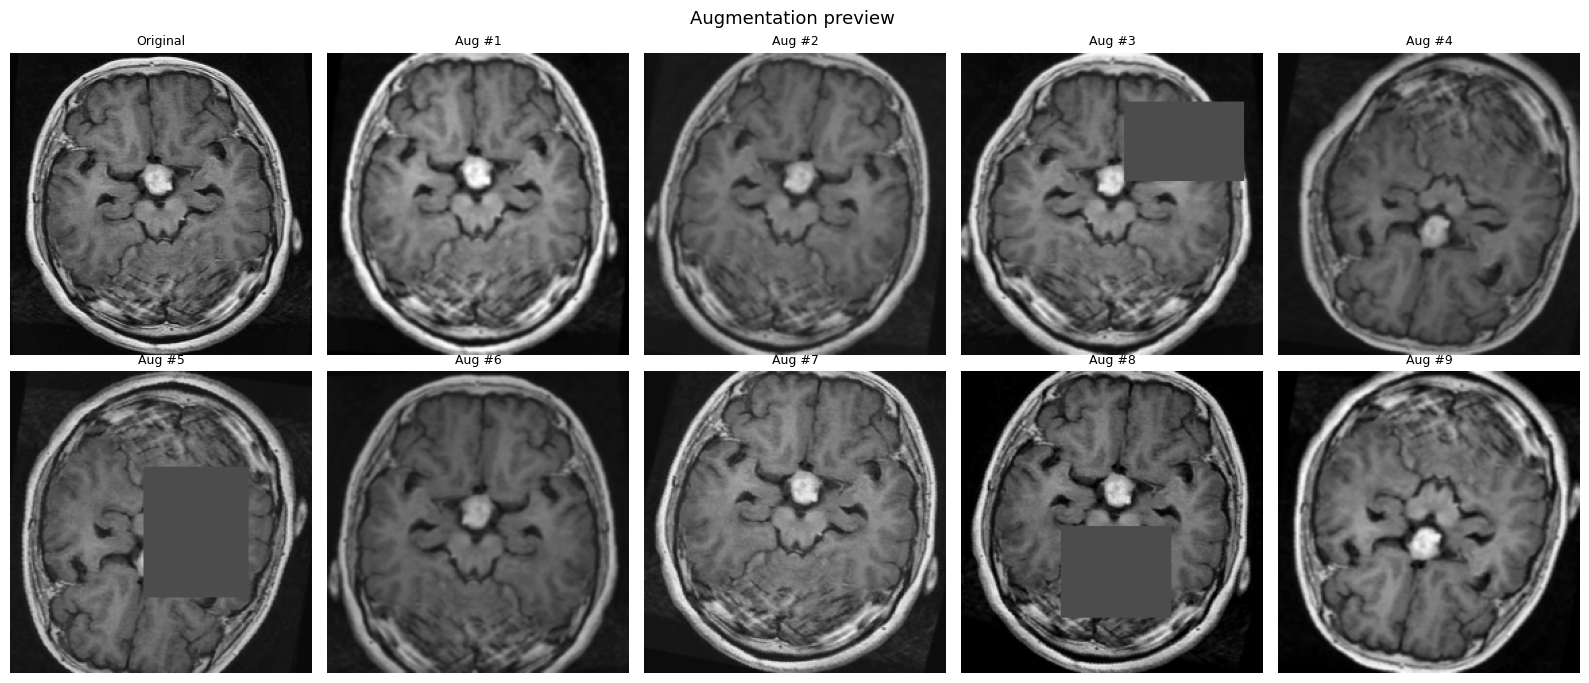

In [9]:
def denormalize(tensor, mean, std):
    img = tensor.clone().permute(1, 2, 0).numpy()
    return np.clip(img * np.array(std) + np.array(mean), 0, 1)


sample_raw, _ = load_and_crop(train_paths[0])

fig, axes = plt.subplots(2, 5, figsize=(16, 7))
axes = axes.flatten()

axes[0].imshow(cv2.resize(sample_raw, (IMG_SIZE, IMG_SIZE)))
axes[0].set_title("Original", fontsize=9); axes[0].axis("off")

for i in range(1, 10):
    aug = train_transforms(sample_raw)
    axes[i].imshow(denormalize(aug, np.array(DATASET_MEAN), np.array(DATASET_STD)))
    axes[i].set_title(f"Aug #{i}", fontsize=9); axes[i].axis("off")

plt.suptitle("Augmentation preview ", fontsize=13)
plt.tight_layout(); plt.show()

### Cache Configuration

In [10]:

ENABLE_CACHE = True

def estimate_cache_memory_gb(paths: list, img_size: int = IMG_SIZE) -> float:
    
    sampled = random.sample(paths, min(20, len(paths)))
    sizes   = []
    for p in sampled:
        try:
            img, _ = load_and_crop(p)   # returns HWC RGB numpy array
            sizes.append(img.shape[0] * img.shape[1] * 3)
        except Exception:
            pass
    avg_bytes = np.mean(sizes) if sizes else img_size * img_size * 3
    return (len(paths) * avg_bytes) / (1024 ** 3)


all_cache_paths = train_paths + val_paths + test_paths
est_gb = estimate_cache_memory_gb(all_cache_paths)
print(f"Estimated cache RAM (real crop sizes): ~{est_gb:.2f} GB")
if est_gb >= 4:
    print("  4 GB — consider setting ENABLE_CACHE = False on low-RAM sessions")
    print("   disabling cache breaks RNG reproducibility — see warning above)")
else:
    print("  Safe to cache")


def build_cache(paths: list) -> dict:
    cache = {}
    for path in tqdm(paths, desc="Caching crops"):
        try:
            img, _ = load_and_crop(path)
            cache[path] = img
        except Exception as e:
            print(f"  Cache failed: {path}: {e}")
            cache[path] = None
    return cache


crop_cache = build_cache(all_cache_paths) if ENABLE_CACHE else {}
print(f"Cache entries : {len(crop_cache)}")
print(f"Cache active  : {ENABLE_CACHE}")


Estimated cache RAM (real crop sizes): ~2.95 GB
  Safe to cache


Caching crops: 100%|██████████| 7200/7200 [01:07<00:00, 106.99it/s]

Cache entries : 7200
Cache active  : True


### Dataset & DataLoader Classes

In [11]:
class BrainTumorDataset(Dataset):
   

    def __init__(self, paths, labels, transform,
                 class_names=None, cache=None):
        self.paths        = paths
        self.labels       = labels
        self.transform    = transform
        self.class_names  = class_names if class_names is not None else BINARY_CLASS_NAMES
        self.cache        = cache if cache is not None else {}
        self._error_count = 0

    def __len__(self):
        return len(self.paths)

    def reset_error_count(self):
        self._error_count = 0

    def report_errors(self):
        if self._error_count > 0:
            print(f"  [{self.__class__.__name__}] {self._error_count} zero-tensor "
                  f"fallbacks this epoch — check corrupt images or transform bugs.")
        else:
            print(f"  [{self.__class__.__name__}] No load errors this epoch.")

    def __getitem__(self, idx):
        img_path = self.paths[idx]
        label    = self.labels[idx]
        try:
            cached = self.cache.get(img_path)
            img    = cached if cached is not None else load_and_crop(img_path)[0]
            img    = self.transform(img)
        except Exception as e:
            self._error_count += 1
            if self._error_count % 10 == 0:
                print(f"  {self._error_count} load failures so far "
                      f"(latest: idx={idx} | {img_path} | {e})")
            img = torch.zeros(3, IMG_SIZE, IMG_SIZE)
        return img, label

    def get_class_name(self, idx):
        return self.class_names[self.labels[idx]]


train_dataset = BrainTumorDataset(train_paths, train_labels, train_transforms,
                                   class_names=BINARY_CLASS_NAMES, cache=crop_cache)
val_dataset   = BrainTumorDataset(val_paths,   val_labels,   eval_transforms,
                                   class_names=BINARY_CLASS_NAMES, cache=crop_cache)
test_dataset  = BrainTumorDataset(test_paths,  test_labels,  eval_transforms,
                                   class_names=BINARY_CLASS_NAMES, cache=crop_cache)

print(f"Train dataset : {len(train_dataset)} samples")
print(f"Val   dataset : {len(val_dataset)} samples")
print(f"Test  dataset : {len(test_dataset)} samples")
print(f"Label space   : {set(train_labels)}  (0=No Tumor, 1=Tumor)")


Train dataset : 4760 samples
Val   dataset : 840 samples
Test  dataset : 1600 samples
Label space   : {0, 1}  (0=No Tumor, 1=Tumor)


### Class Weights & DataLoaders

In [12]:
class_counts = Counter(train_labels)
total        = sum(class_counts.values())

_no_tumor_count = class_counts[NO_TUMOR_LABEL]
_tumor_count    = class_counts[TUMOR_LABEL]
POS_WEIGHT      = _no_tumor_count / _tumor_count   # ~3x for this dataset, dataset-level ratio only


EFFECTIVE_POS_WEIGHT = 1.0

print(f"Dataset imbalance ratio       : {POS_WEIGHT:.4f}  "
      f"(No-Tumor={_no_tumor_count} / Tumor={_tumor_count})")
print(f"pos_weight actually used in loss : {EFFECTIVE_POS_WEIGHT}  "
      f"(sampler already balances batches — not double-correcting)")

print("Binary class weights:")
for cls_idx, count in sorted(class_counts.items()):
    name = BINARY_CLASS_NAMES[cls_idx]   # FIX: use BINARY_CLASS_NAMES not CLASSES
    print(f"  {name:>12s} (label={cls_idx}): {count} samples  weight={total/count:.4f}")

sample_weights = torch.tensor(
    [1.0 / class_counts[label] for label in train_labels],
    dtype=torch.float
)

sampler = WeightedRandomSampler(
    weights=sample_weights,
    num_samples=len(sample_weights),
    replacement=True
)

PERSISTENT = NUM_WORKERS > 0

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE,
                          sampler=sampler, num_workers=NUM_WORKERS,
                          pin_memory=True, persistent_workers=PERSISTENT,
                          drop_last=True)   # FIX: avoid a possible batch_size=1 last batch
                                            # crashing BatchNorm1d in the head

val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=True,
                          persistent_workers=PERSISTENT)

test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=True,
                          persistent_workers=PERSISTENT)

print(f"\nTrain batches : {len(train_loader)}  (drop_last=True)")
print(f"Val   batches : {len(val_loader)}")
print(f"Test  batches : {len(test_loader)}")


Dataset imbalance ratio       : 0.3333  (No-Tumor=1190 / Tumor=3570)
pos_weight actually used in loss : 1.0  (sampler already balances batches — not double-correcting)
Binary class weights:
      No Tumor (label=0): 1190 samples  weight=4.0000
         Tumor (label=1): 3570 samples  weight=1.3333

Train batches : 148  (drop_last=True)
Val   batches : 27
Test  batches : 50


### Batch Sanity Check

Batch shape      : torch.Size([32, 3, 224, 224])
Labels           : [1, 1, 1, 1, 1, 0, 1, 0, 1, 0, 1, 0, 1, 1, 0, 0, 0, 1, 1, 1, 1, 1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0]
Pixel range      : [-1.274, 2.979]
Pixel mean       : 0.010  (should be ≈ 0 after Normalize)
Pixel std        : 0.924   (should be ≈ 1)

WeightedSampler balance check:
      No Tumor: 85
         Tumor: 75


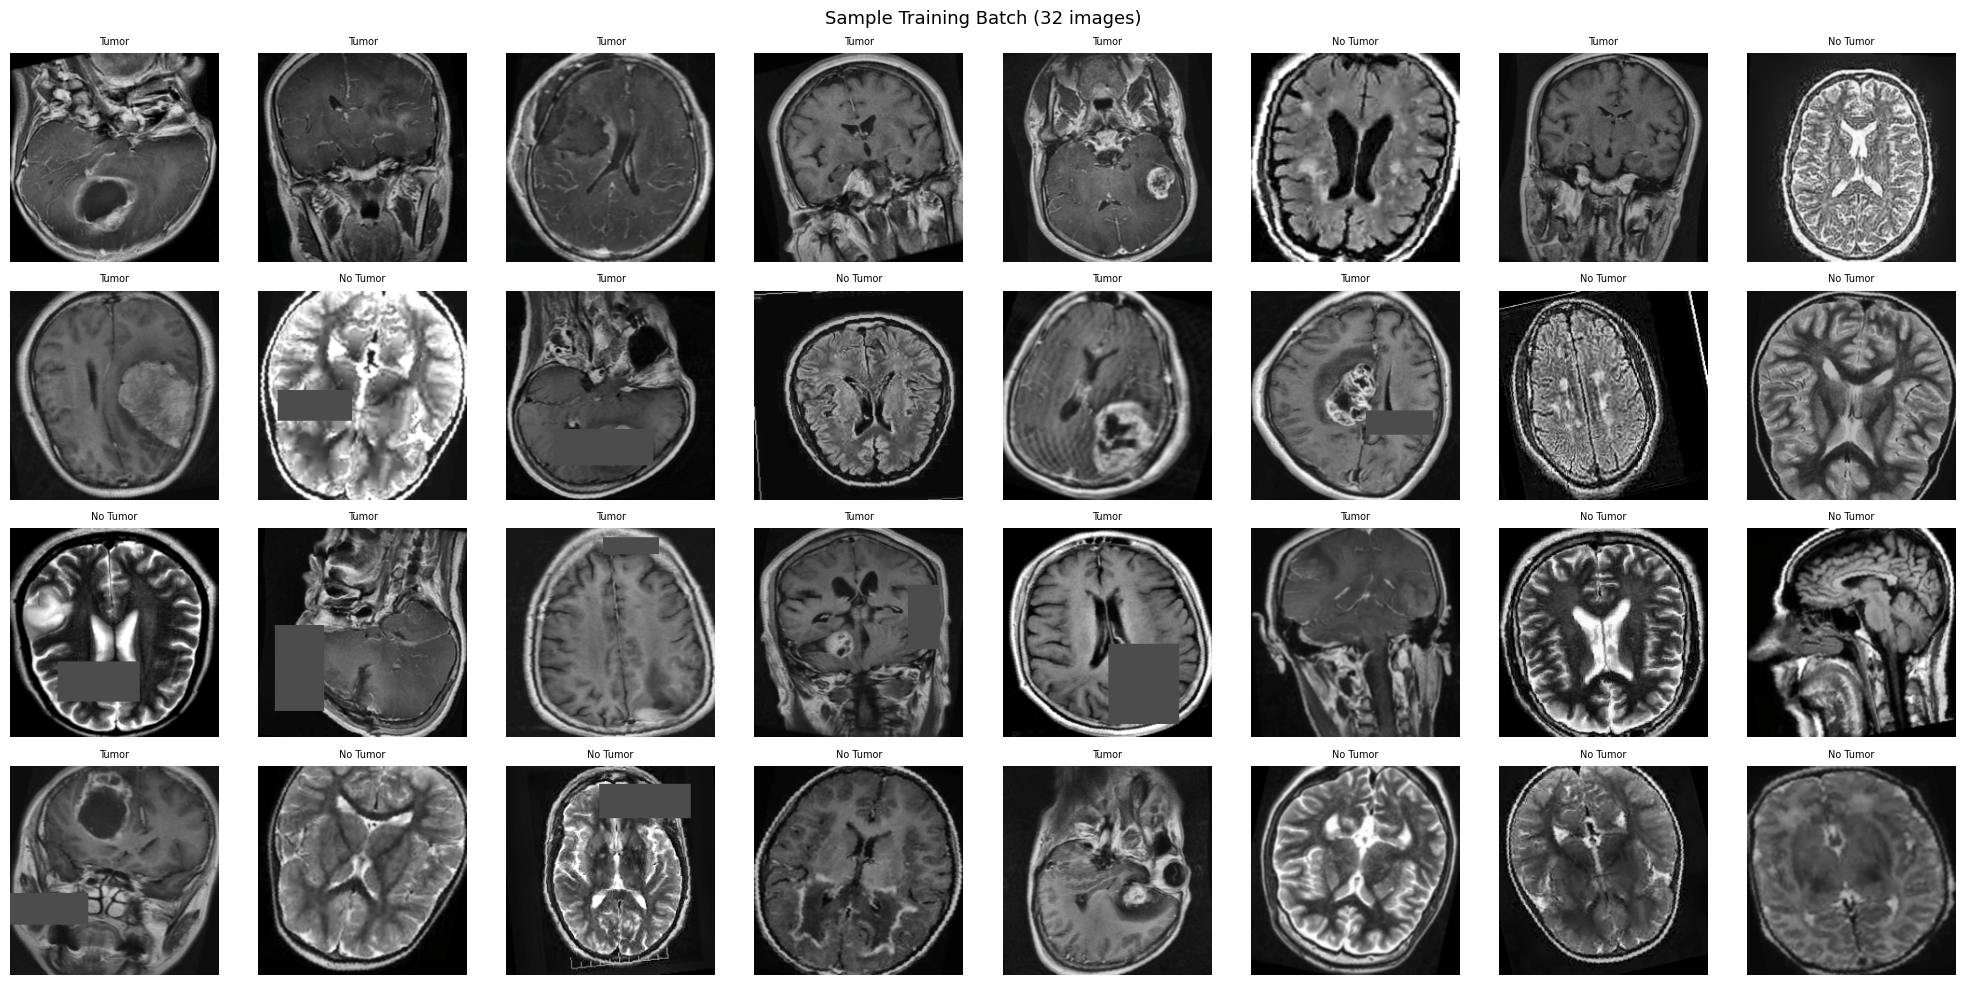

In [13]:
imgs, batch_labels = next(iter(train_loader))

print(f"Batch shape      : {imgs.shape}")          # [32, 3, 224, 224]
print(f"Labels           : {batch_labels.tolist()}")
print(f"Pixel range      : [{imgs.min():.3f}, {imgs.max():.3f}]")
print(f"Pixel mean       : {imgs.mean():.3f}  (should be ≈ 0 after Normalize)")
print(f"Pixel std        : {imgs.std():.3f}   (should be ≈ 1)")

print("\nWeightedSampler balance check:")
seen = Counter()
for i, (_, lbls) in enumerate(train_loader):
    seen.update(lbls.tolist())
    if i == 4: break

for cls_idx, cnt in sorted(seen.items()):
    print(f"  {BINARY_CLASS_NAMES[cls_idx]:>12s}: {cnt}")

fig, axes = plt.subplots(4, 8, figsize=(20, 10))
axes = axes.flatten()
for i in range(min(32, len(imgs))):
    axes[i].imshow(denormalize(imgs[i], DATASET_MEAN, DATASET_STD))
    axes[i].set_title(BINARY_CLASS_NAMES[batch_labels[i].item()], fontsize=7)
    axes[i].axis("off")
plt.suptitle("Sample Training Batch (32 images)", fontsize=13)
plt.tight_layout(); plt.show()

### TTA Pipeline

In [14]:


def _tta_transforms(n_views: int = 5):
   
    base = [
        transforms.ToPILImage(),
        transforms.Resize((IMG_SIZE, IMG_SIZE)),
        transforms.ToTensor(),
        transforms.Normalize(mean=DATASET_MEAN, std=DATASET_STD),
    ]

    def compose(extra_pil_ops):
       
        return transforms.Compose([base[0]] + extra_pil_ops + base[1:])

    pipelines = [
        transforms.Compose(base),                                                      
        compose([transforms.RandomHorizontalFlip(p=1.0)]),                           
        compose([transforms.RandomVerticalFlip(p=1.0)]),                              
        compose([transforms.RandomHorizontalFlip(p=1.0),                              
                 transforms.RandomVerticalFlip(p=1.0)]),
        compose([transforms.RandomRotation(degrees=10)]),                             
    ]
    return pipelines[:n_views]


def tta_predict(model, data_loader, device,
                n_views: int = 5, threshold: float = 0.5):
   
    tta_pipes  = _tta_transforms(n_views)
    model.eval()
    all_probs  = []
    all_labels = []

    with torch.no_grad():
        for paths_batch, labels_batch in tqdm(data_loader, desc=f"TTA ({n_views} views)"):
            # paths_batch must be a list of file paths — see note below
            batch_probs = torch.zeros(len(paths_batch), device=device)

            for pipe in tta_pipes:
                imgs = []
                for p in paths_batch:
                    raw, _ = load_and_crop(p)
                    imgs.append(pipe(raw))
                imgs = torch.stack(imgs).to(device)
                logits = model(imgs).squeeze(1)   # shape (B,)
                batch_probs += torch.sigmoid(logits)

            batch_probs /= n_views
            all_probs.append(batch_probs.cpu().numpy())
            all_labels.append(labels_batch.numpy())

    probs  = np.concatenate(all_probs)
    labels = np.concatenate(all_labels)
    preds  = (probs >= threshold).astype(int)
    return probs, preds, labels



class PathAwareDataset(Dataset):

    def __init__(self, paths, labels):
        self.paths  = paths
        self.labels = labels

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, idx):
        return self.paths[idx], self.labels[idx]


tta_test_dataset = PathAwareDataset(test_paths, test_labels)
tta_test_loader  = DataLoader(tta_test_dataset, batch_size=BATCH_SIZE,
                               shuffle=False, num_workers=0,  # 0 workers: paths are strings
                               collate_fn=lambda b: (
                                   [x[0] for x in b],        # list of paths
                                   torch.tensor([x[1] for x in b])
                               ))

print(f"  Views per image : 5  (original, H-flip, V-flip, HV-flip, rotation)")
print(f"  Default threshold : 0.5  (lower to ~0.35 to maximise recall)")
print(f"  Usage after training:")
print(f"    probs, preds, labels = tta_predict(model, tta_test_loader, device)")


  Views per image : 5  (original, H-flip, V-flip, HV-flip, rotation)
  Default threshold : 0.5  (lower to ~0.35 to maximise recall)
  Usage after training:
    probs, preds, labels = tta_predict(model, tta_test_loader, device)


---
# Part 2 >> Model Training & Evaluation 


### Extra imports & device setup

In [15]:
import os, random, warnings
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.amp import GradScaler, autocast          # FIX 1: updated import
from torchvision import models
from torchvision.models import EfficientNet_B3_Weights
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report, roc_curve
)
from tqdm import tqdm
import cv2
warnings.filterwarnings("ignore")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
AMP_DEVICE = "cuda" if torch.cuda.is_available() else "cpu"   # FIX 2: for autocast
print(f"Device : {device}")
if torch.cuda.is_available():
    print(f"GPU    : {torch.cuda.get_device_name(0)}")
    print(f"VRAM   : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

def set_seed(seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(SEED)

Device : cuda
GPU    : Tesla T4
VRAM   : 15.6 GB


### Hyper-parameters

In [16]:
# Stage 1: Head-only training (backbone frozen)
STAGE1_EPOCHS   = 10
STAGE1_LR       = 3e-4
STAGE1_WD       = 1e-4

# Stage 2: Fine-tune upper layers
STAGE2_EPOCHS   = 30
STAGE2_LR       = 5e-5
STAGE2_WD       = 1e-4

# Shared
GRAD_CLIP       = 1.0
LABEL_SMOOTHING = 0.05
PATIENCE        = 8
MIN_DELTA       = 1e-4
RECALL_WEIGHT   = 0.7      
CHECKPOINT_DIR  = "/kaggle/working"
BEST_MODEL_PATH = f"{CHECKPOINT_DIR}/best_brain_tumor_b3.pth"

print(f"  Step 1 : {STAGE1_EPOCHS} epochs  LR={STAGE1_LR}  WD={STAGE1_WD}")
print(f"  Step 2 : {STAGE2_EPOCHS} epochs  LR={STAGE2_LR}  WD={STAGE2_WD}")
print(f"  Grad clip       : {GRAD_CLIP}")
print(f"  Label smoothing : {LABEL_SMOOTHING}")
print(f"  Early stop      : patience={PATIENCE}  min_delta={MIN_DELTA}")

  Step 1 : 10 epochs  LR=0.0003  WD=0.0001
  Step 2 : 30 epochs  LR=5e-05  WD=0.0001
  Grad clip       : 1.0
  Label smoothing : 0.05
  Early stop      : patience=8  min_delta=0.0001


### Model definition

In [17]:
class BrainTumorB3(nn.Module):
    

    def __init__(self, dropout: float = 0.4):
        super().__init__()
        backbone    = models.efficientnet_b3(weights=EfficientNet_B3_Weights.IMAGENET1K_V1)
        self.features  = backbone.features
        self.avgpool   = backbone.avgpool
        in_features    = backbone.classifier[1].in_features   # 1536 for B3

        self.head = nn.Sequential(
            nn.BatchNorm1d(in_features),
            nn.Dropout(p=dropout),
            nn.Linear(in_features, 1),
        )
        self._init_head()

      
        self._frozen_blocks = []

    def _init_head(self):
        for m in self.head.modules():
            if isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight)
                nn.init.zeros_(m.bias)
            elif isinstance(m, nn.BatchNorm1d):
                nn.init.ones_(m.weight)
                nn.init.zeros_(m.bias)

    def train(self, mode: bool = True):
       
        super().train(mode)
        if mode:
            for block in self._frozen_blocks:
                block.eval()
        return self

    def freeze_backbone(self):
        
        for p in self.features.parameters():
            p.requires_grad = False
        for p in self.head.parameters():
            p.requires_grad = True

        self._frozen_blocks = [self.features]   # FIX: lock BN stats too
        self.features.eval()
        print("Backbone FROZEN ")

    def unfreeze_top_n_blocks(self, n: int = 3):
       
        for p in self.features.parameters():
            p.requires_grad = False

        children          = list(self.features.children())
        frozen_children   = children[:-n]
        unfrozen_children = children[-n:]

        for block in unfrozen_children:
            for p in block.parameters():
                p.requires_grad = True
        for p in self.head.parameters():
            p.requires_grad = True

       
        self._frozen_blocks = frozen_children
        for block in frozen_children:
            block.eval()
        for block in unfrozen_children:
            block.train()

        trainable = sum(p.numel() for p in self.parameters() if p.requires_grad)
        total     = sum(p.numel() for p in self.parameters())
        print(f"Fine-tuning: last {n} feature blocks + head unlocked.")
        print(f"  Trainable : {trainable:,} / {total:,}  ({100*trainable/total:.1f}%)")
        print(f"  Frozen blocks kept in eval() mode: {len(frozen_children)}/{len(children)}")

    def forward(self, x):
        x = self.features(x)
        x = self.avgpool(x)
        x = torch.flatten(x, 1)
        return self.head(x)   


model = BrainTumorB3(dropout=0.4).to(device)
print(f"EfficientNet-B3 ready.  Total params: {sum(p.numel() for p in model.parameters()):,}")


Downloading: "https://download.pytorch.org/models/efficientnet_b3_rwightman-b3899882.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b3_rwightman-b3899882.pth


100%|██████████| 47.2M/47.2M [00:00<00:00, 184MB/s]


EfficientNet-B3 ready.  Total params: 10,700,841


### Loss function

In [18]:
class LabelSmoothBCE(nn.Module):
   
    def __init__(self, pos_weight: float, smoothing: float = 0.0):
        super().__init__()
        self.smoothing = smoothing
        self.bce = nn.BCEWithLogitsLoss(
            pos_weight=torch.tensor([pos_weight])
        )

    def forward(self, logits: torch.Tensor, targets: torch.Tensor) -> torch.Tensor:
        logits  = logits.squeeze(1).float()    # (B,1) → (B,)
        targets = targets.float()
        if self.smoothing > 0:
            targets = targets * (1.0 - self.smoothing) + 0.5 * self.smoothing
        return self.bce(logits, targets)


criterion = LabelSmoothBCE(pos_weight=EFFECTIVE_POS_WEIGHT, smoothing=LABEL_SMOOTHING).to(device)
print(f"Loss: BCEWithLogitsLoss + LabelSmoothing(ε={LABEL_SMOOTHING})")
print(f"  pos_weight used : {EFFECTIVE_POS_WEIGHT}  "
      f"(dataset ratio {POS_WEIGHT:.4f} not applied — sampler already balances batches)")

Loss: BCEWithLogitsLoss + LabelSmoothing(ε=0.05)
  pos_weight used : 1.0  (dataset ratio 0.3333 not applied — sampler already balances batches)


### Metrics helper

In [19]:
def compute_metrics(probs: np.ndarray, preds: np.ndarray,
                    targets: np.ndarray, threshold: float = 0.5) -> dict:
   
    cm_mat = confusion_matrix(targets, preds, labels=[0, 1])
    tn, fp, fn, tp = cm_mat.ravel()
    specificity = tn / (tn + fp + 1e-8)

    return {
        "accuracy"   : accuracy_score(targets, preds),
        "precision"  : precision_score(targets, preds, zero_division=0),
        "recall"     : recall_score(targets, preds, zero_division=0),
        "specificity": specificity,
        "f1"         : f1_score(targets, preds, zero_division=0),
        "roc_auc"    : roc_auc_score(targets, probs),
        "confusion"  : cm_mat,
        "threshold"  : threshold,
    }


def composite_score(metrics: dict) -> float:
    return RECALL_WEIGHT * metrics["recall"] + (1 - RECALL_WEIGHT) * metrics["roc_auc"]


def print_metrics(metrics: dict, split: str = ""):
    tag = f"[{split}] " if split else ""
    print(f"\n{tag}Metrics  (threshold={metrics['threshold']:.2f})")
    print(f"  Accuracy    : {metrics['accuracy']:.4f}")
    print(f"  Precision   : {metrics['precision']:.4f}")
    print(f"  Recall(Sen) : {metrics['recall']:.4f}  ← medical priority")
    print(f"  Specificity : {metrics['specificity']:.4f}")
    print(f"  F1 Score    : {metrics['f1']:.4f}")
    print(f"  ROC-AUC     : {metrics['roc_auc']:.4f}")
    print(f"  Composite   : {composite_score(metrics):.4f}  (0.7×Recall + 0.3×AUC)")
    cm = metrics["confusion"]
    print(f"\n  Confusion Matrix:")
    print(f"              Pred 0    Pred 1")
    print(f"  True 0  :   TN={cm[0,0]:>5d}   FP={cm[0,1]:>5d}")
    print(f"  True 1  :   FN={cm[1,0]:>5d}   TP={cm[1,1]:>5d}")


def plot_confusion_matrix(metrics: dict, title: str = "Confusion Matrix"):
    cm = metrics["confusion"]
    fig, ax = plt.subplots(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax,
                xticklabels=BINARY_CLASS_NAMES,
                yticklabels=BINARY_CLASS_NAMES)
    ax.set_xlabel("Predicted"); ax.set_ylabel("Actual")
    ax.set_title(f"{title}\n(Recall={metrics['recall']:.3f}  AUC={metrics['roc_auc']:.3f})")
    plt.tight_layout(); plt.show()

### Core train / eval loops

In [20]:
def train_one_epoch(model, loader, optimizer, criterion, scaler,
                    scheduler=None, mixup_alpha: float = 0.3,
                    grad_clip: float = 1.0) -> dict:
   
    model.train()
    running_loss = 0.0
    all_probs, all_preds, all_targets = [], [], []

    for imgs, labels in tqdm(loader, desc="  train", leave=False):
        imgs   = imgs.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        if mixup_alpha > 0:
            imgs, labels_a, labels_b, lam = mixup_batch(imgs, labels, mixup_alpha)
        else:
            labels_a = labels_b = labels
            lam = 1.0

        optimizer.zero_grad(set_to_none=True)

        with autocast(device_type=AMP_DEVICE):                   
            logits = model(imgs).squeeze(1)                       
            loss   = lam * criterion(logits, labels_a) + \
                     (1 - lam) * criterion(logits, labels_b)

        scaler.scale(loss).backward()

        if grad_clip > 0:
            scaler.unscale_(optimizer)
            nn.utils.clip_grad_norm_(model.parameters(), grad_clip)

        scaler.step(optimizer)
        scaler.update()

        if scheduler is not None and isinstance(
                scheduler, torch.optim.lr_scheduler.OneCycleLR):
            scheduler.step()

        probs = torch.sigmoid(logits.detach().float())
        preds = (probs >= 0.5).long()
        all_probs.append(probs.cpu().numpy())
        all_preds.append(preds.cpu().numpy())
        all_targets.append(labels.cpu().numpy())
        running_loss += loss.item() * imgs.size(0)

    probs   = np.concatenate(all_probs)
    preds   = np.concatenate(all_preds)
    targets = np.concatenate(all_targets)

    metrics         = compute_metrics(probs, preds, targets)
    metrics["loss"] = running_loss / len(loader.dataset)
    return metrics


@torch.no_grad()
def evaluate(model, loader, criterion, threshold: float = 0.5) -> dict:
    
    model.eval()
    running_loss = 0.0
    all_probs, all_preds, all_targets = [], [], []

    for imgs, labels in tqdm(loader, desc="  eval", leave=False):
        imgs   = imgs.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        with autocast(device_type=AMP_DEVICE):                 
            logits = model(imgs).squeeze(1)                    
            loss   = criterion(logits, labels.float())

        probs = torch.sigmoid(logits.float())
        preds = (probs >= threshold).long()

        all_probs.append(probs.cpu().numpy())
        all_preds.append(preds.cpu().numpy())
        all_targets.append(labels.cpu().numpy())
        running_loss += loss.item() * imgs.size(0)

    probs   = np.concatenate(all_probs)
    preds   = np.concatenate(all_preds)
    targets = np.concatenate(all_targets)

    metrics          = compute_metrics(probs, preds, targets, threshold)
    metrics["loss"]  = running_loss / len(loader.dataset)
    metrics["probs"] = probs
    return metrics

### Early stopping & checkpoint helpers

In [21]:
class EarlyStopping:
   
    def __init__(self, patience: int = 8, min_delta: float = 1e-4,
                 checkpoint_path: str = BEST_MODEL_PATH):
        self.patience   = patience
        self.min_delta  = min_delta
        self.ckpt_path  = checkpoint_path
        self.best_score = -np.inf
        self.counter    = 0
        self.best_epoch = 0
        self.stopped    = False

    def step(self, score: float, model, epoch: int) -> bool:
        if score > self.best_score + self.min_delta:
            self.best_score = score
            self.counter    = 0
            self.best_epoch = epoch
            torch.save(model.state_dict(), self.ckpt_path)
            print(f"  New best composite={score:.4f}  → checkpoint saved")
        else:
            self.counter += 1
            print(f"  No improvement ({self.counter}/{self.patience})  "
                  f"best={self.best_score:.4f}")
            if self.counter >= self.patience:
                self.stopped = True
        return self.stopped


def load_best_model(model, path: str = BEST_MODEL_PATH):
    model.load_state_dict(torch.load(path, map_location=device, weights_only=True))
    model.to(device)
    print(f"Best model loaded from {path}")
    return model


def plot_history(history: dict, stage: int):
    epochs = range(1, len(history["train_loss"]) + 1)
    fig, axes = plt.subplots(1, 3, figsize=(17, 4))

    axes[0].plot(epochs, history["train_loss"], label="Train")
    axes[0].plot(epochs, history["val_loss"],   label="Val")
    axes[0].set_title(f"Stage {stage} — Loss"); axes[0].legend()

    axes[1].plot(epochs, history["val_recall"], label="Recall", color="red")
    axes[1].plot(epochs, history["val_auc"],    label="AUC",    color="blue")
    axes[1].plot(epochs, history["val_f1"],     label="F1",     color="green")
    axes[1].set_title(f"Stage {stage} — Val Metrics"); axes[1].legend()

    axes[2].plot(epochs, history["composite"],  label="Composite", color="purple")
    axes[2].set_title(f"Stage {stage} — Composite Score"); axes[2].legend()

    plt.suptitle(f"Training History — Stage {stage}", fontsize=13)
    plt.tight_layout(); plt.show()

### Stage 1: Train classifier head (frozen backbone)

In [22]:
def forward(self, logits: torch.Tensor, targets: torch.Tensor) -> torch.Tensor:
    logits  = logits.reshape(-1).float()    
    targets = targets.float()
    if self.smoothing > 0:
        targets = targets * (1.0 - self.smoothing) + 0.5 * self.smoothing
    return self.bce(logits, targets)

In [23]:
class LabelSmoothBCE(nn.Module):
    def __init__(self, pos_weight: float, smoothing: float = 0.0):
        super().__init__()
        self.smoothing = smoothing
        self.bce = nn.BCEWithLogitsLoss(
            pos_weight=torch.tensor([pos_weight])
        )

    def forward(self, logits: torch.Tensor, targets: torch.Tensor) -> torch.Tensor:
        logits  = logits.reshape(-1).float()   
        targets = targets.float()
        if self.smoothing > 0:
            targets = targets * (1.0 - self.smoothing) + 0.5 * self.smoothing
        return self.bce(logits, targets)

criterion = LabelSmoothBCE(pos_weight=EFFECTIVE_POS_WEIGHT, smoothing=LABEL_SMOOTHING).to(device)


 Training classification head
Backbone FROZEN 

Epoch 1/10  LR=3.00e-05


  Train  loss=0.9315  recall=0.5142
  Val    loss=0.5353  recall=0.8286  auc=0.8088  composite=0.8227
  New best composite=0.8227  → checkpoint saved

Epoch 2/10  LR=9.78e-05


  Train  loss=0.6226  recall=0.5940
  Val    loss=0.3528  recall=0.9111  auc=0.9317  composite=0.9173
  New best composite=0.9173  → checkpoint saved

Epoch 3/10  LR=2.33e-04


  Train  loss=0.4949  recall=0.6521
  Val    loss=0.2751  recall=0.9460  auc=0.9651  composite=0.9517
  New best composite=0.9517  → checkpoint saved

Epoch 4/10  LR=3.00e-04


  Train  loss=0.4461  recall=0.7101
  Val    loss=0.2514  recall=0.9476  auc=0.9781  composite=0.9568
  New best composite=0.9568  → checkpoint saved

Epoch 5/10  LR=2.85e-04


...

  Train  loss=0.4268  recall=0.7014
  Val    loss=0.2277  recall=0.9619  auc=0.9862  composite=0.9692
  New best composite=0.9692  → checkpoint saved

Epoch 7/10  LR=1.83e-04


  Train  loss=0.4024  recall=0.7000
  Val    loss=0.2175  recall=0.9714  auc=0.9879  composite=0.9764
  New best composite=0.9764  → checkpoint saved

Epoch 8/10  LR=1.16e-04


  Train  loss=0.3934  recall=0.7312
  Val    loss=0.2091  recall=0.9794  auc=0.9898  composite=0.9825
  New best composite=0.9825  → checkpoint saved

Epoch 9/10  LR=5.64e-05


  Train  loss=0.3706  recall=0.7401
  Val    loss=0.2157  recall=0.9635  auc=0.9892  composite=0.9712
  No improvement (1/8)  best=0.9825

Epoch 10/10  LR=1.49e-05


  Train  loss=0.4148  recall=0.7156
  Val    loss=0.2129  recall=0.9714  auc=0.9891  composite=0.9767
  No improvement (2/8)  best=0.9825

 complete.  Best composite=0.9825 (epoch 8)


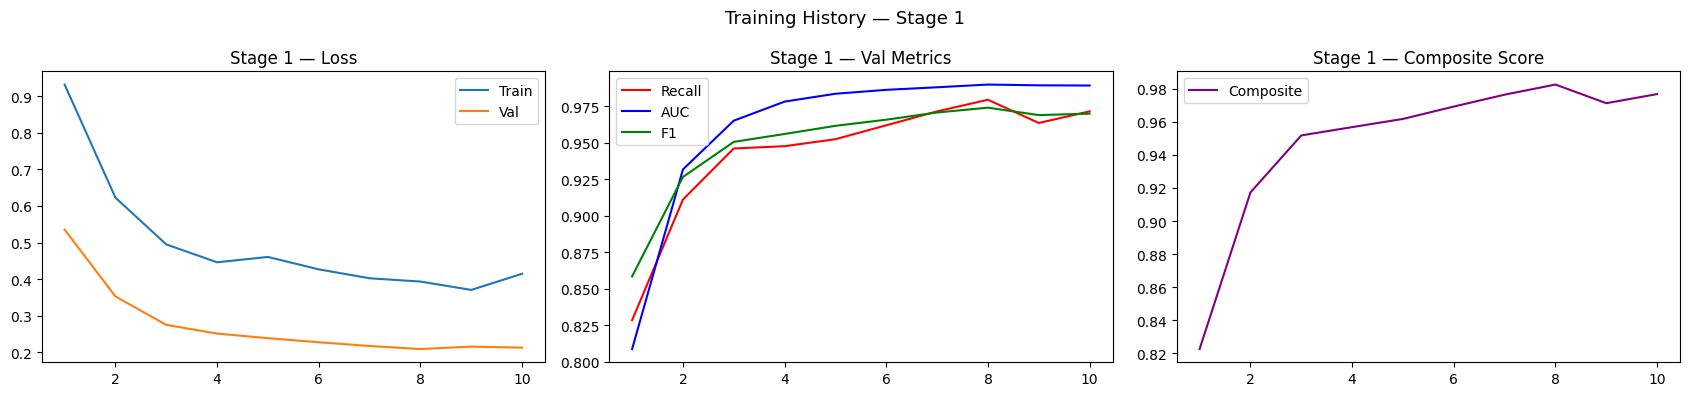

In [24]:
print(" Training classification head")

set_seed(SEED)
model.freeze_backbone()

optimizer_s1 = torch.optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=STAGE1_LR, weight_decay=STAGE1_WD, amsgrad=True
)

scheduler_s1 = torch.optim.lr_scheduler.OneCycleLR(
    optimizer_s1,
    max_lr=STAGE1_LR,
    steps_per_epoch=len(train_loader),
    epochs=STAGE1_EPOCHS,
    pct_start=0.3,
    anneal_strategy="cos",
    div_factor=10,
    final_div_factor=100,
)

scaler_s1 = GradScaler(device=AMP_DEVICE)          # FIX 3: device=AMP_DEVICE
es_s1     = EarlyStopping(patience=PATIENCE, min_delta=MIN_DELTA,
                           checkpoint_path=BEST_MODEL_PATH)
history_s1 = {
    "train_loss": [], "val_loss": [],
    "val_recall": [], "val_auc": [], "val_f1": [],
    "composite": [],
}

for epoch in range(1, STAGE1_EPOCHS + 1):
    print(f"\nEpoch {epoch}/{STAGE1_EPOCHS}  "
          f"LR={scheduler_s1.get_last_lr()[0]:.2e}")

    tr = train_one_epoch(model, train_loader, optimizer_s1, criterion,
                         scaler_s1, scheduler=scheduler_s1,
                         mixup_alpha=MIXUP_ALPHA, grad_clip=GRAD_CLIP)
    vl = evaluate(model, val_loader, criterion, threshold=0.5)
    cs = composite_score(vl)

    history_s1["train_loss"].append(tr["loss"])
    history_s1["val_loss"].append(vl["loss"])
    history_s1["val_recall"].append(vl["recall"])
    history_s1["val_auc"].append(vl["roc_auc"])
    history_s1["val_f1"].append(vl["f1"])
    history_s1["composite"].append(cs)

    print(f"  Train  loss={tr['loss']:.4f}  recall={tr['recall']:.4f}")
    print(f"  Val    loss={vl['loss']:.4f}  recall={vl['recall']:.4f}  "
          f"auc={vl['roc_auc']:.4f}  composite={cs:.4f}")

    if es_s1.step(cs, model, epoch):
        print(f"\nEarly stopping — best at epoch {es_s1.best_epoch}")
        break

print(f"\n complete.  Best composite={es_s1.best_score:.4f} "
      f"(epoch {es_s1.best_epoch})")
plot_history(history_s1, stage=1)

### Stage 2: Fine-tune upper blocks

Fine-tuning
Best model loaded from /kaggle/working/best_brain_tumor_b3.pth
Fine-tuning: last 3 feature blocks + head unlocked.
  Trainable : 8,510,687 / 10,700,841  (79.5%)
  Frozen blocks kept in eval() mode: 6/9

Epoch 1/30  LR_head=5.00e-05


  Train  loss=0.4554  recall=0.6937
  Val    loss=0.2619  recall=0.9508  auc=0.9792  composite=0.9593
  New best composite=0.9593  → checkpoint saved

Epoch 2/30  LR_head=4.99e-05


  Train  loss=0.3747  recall=0.7325
  Val    loss=0.2385  recall=0.9540  auc=0.9854  composite=0.9634
  New best composite=0.9634  → checkpoint saved

Epoch 3/30  LR_head=4.95e-05


  Train  loss=0.3614  recall=0.7531
  Val    loss=0.2334  recall=0.9571  auc=0.9884  composite=0.9665
  New best composite=0.9665  → checkpoint saved

Epoch 4/30  LR_head=4.88e-05


  Train  loss=0.3635  recall=0.6841
  Val    loss=0.2377  recall=0.9444  auc=0.9905  composite=0.9582
  No improvement (1/8)  best=0.9665

Epoch 5/30  LR_head=4.78e-05


...

  Train  loss=0.2892  recall=0.7162
  Val    loss=0.1745  recall=0.9873  auc=0.9967  composite=0.9901
  No improvement (4/8)  best=0.9943

Epoch 16/30  LR_head=2.51e-05


  Train  loss=0.2933  recall=0.7444
  Val    loss=0.1786  recall=0.9841  auc=0.9967  composite=0.9879
  No improvement (5/8)  best=0.9943

Epoch 17/30  LR_head=2.24e-05


  Train  loss=0.2829  recall=0.7476
  Val    loss=0.1735  recall=0.9889  auc=0.9974  composite=0.9914
  No improvement (6/8)  best=0.9943

Epoch 18/30  LR_head=1.99e-05


  Train  loss=0.2990  recall=0.7317
  Val    loss=0.1739  recall=0.9873  auc=0.9973  composite=0.9903
  No improvement (7/8)  best=0.9943

Epoch 19/30  LR_head=1.73e-05


  Train  loss=0.2952  recall=0.7340
  Val    loss=0.1710  recall=0.9905  auc=0.9968  composite=0.9924
  No improvement (8/8)  best=0.9943

Early stopping — best at epoch 11

Stage 2 complete.  Best composite=0.9943 (epoch 11)


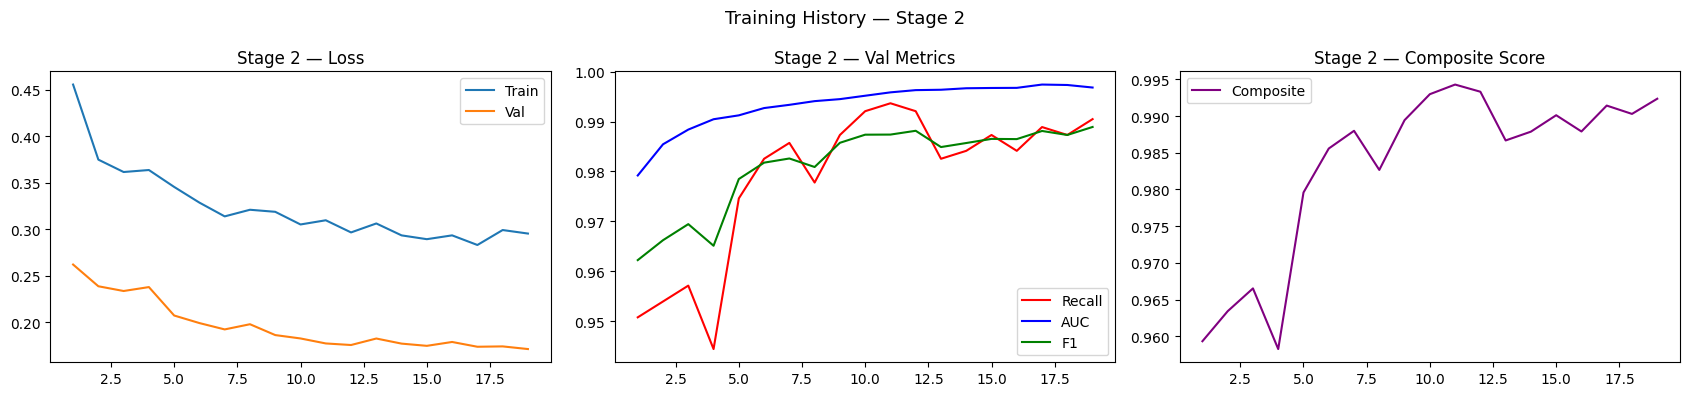

In [25]:
print("Fine-tuning")

model = load_best_model(model, BEST_MODEL_PATH)
model.unfreeze_top_n_blocks(n=3)

head_params     = list(model.head.parameters())
backbone_params = [p for p in model.features.parameters() if p.requires_grad]

optimizer_s2 = torch.optim.AdamW([
    {"params": backbone_params, "lr": STAGE2_LR * 0.1},   # 5e-6 — gentle backbone
    {"params": head_params,     "lr": STAGE2_LR},          # 5e-5 — head
], weight_decay=STAGE2_WD, amsgrad=True)

scheduler_s2 = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer_s2, T_max=STAGE2_EPOCHS, eta_min=1e-7
)

scaler_s2 = GradScaler(device=AMP_DEVICE)          # FIX 3
es_s2     = EarlyStopping(patience=PATIENCE, min_delta=MIN_DELTA,
                           checkpoint_path=BEST_MODEL_PATH)
history_s2 = {
    "train_loss": [], "val_loss": [],
    "val_recall": [], "val_auc": [], "val_f1": [],
    "composite": [],
}

for epoch in range(1, STAGE2_EPOCHS + 1):
    current_lr = optimizer_s2.param_groups[1]["lr"]
    print(f"\nEpoch {epoch}/{STAGE2_EPOCHS}  LR_head={current_lr:.2e}")

    tr = train_one_epoch(model, train_loader, optimizer_s2, criterion,
                         scaler_s2, scheduler=None,
                         mixup_alpha=MIXUP_ALPHA * 0.5,   # softer MixUp in Stage 2
                         grad_clip=GRAD_CLIP)
    vl = evaluate(model, val_loader, criterion, threshold=0.5)
    cs = composite_score(vl)

    history_s2["train_loss"].append(tr["loss"])
    history_s2["val_loss"].append(vl["loss"])
    history_s2["val_recall"].append(vl["recall"])
    history_s2["val_auc"].append(vl["roc_auc"])
    history_s2["val_f1"].append(vl["f1"])
    history_s2["composite"].append(cs)

    print(f"  Train  loss={tr['loss']:.4f}  recall={tr['recall']:.4f}")
    print(f"  Val    loss={vl['loss']:.4f}  recall={vl['recall']:.4f}  "
          f"auc={vl['roc_auc']:.4f}  composite={cs:.4f}")

    scheduler_s2.step()   # CosineAnnealing steps per epoch

    if es_s2.step(cs, model, epoch):
        print(f"\nEarly stopping — best at epoch {es_s2.best_epoch}")
        break

print(f"\nStage 2 complete.  Best composite={es_s2.best_score:.4f} "
      f"(epoch {es_s2.best_epoch})")
plot_history(history_s2, stage=2)

### Threshold calibration on validation set

Loading best model for threshold calibration
Best model loaded from /kaggle/working/best_brain_tumor_b3.pth



Optimal threshold : 0.20  (composite=0.9965)


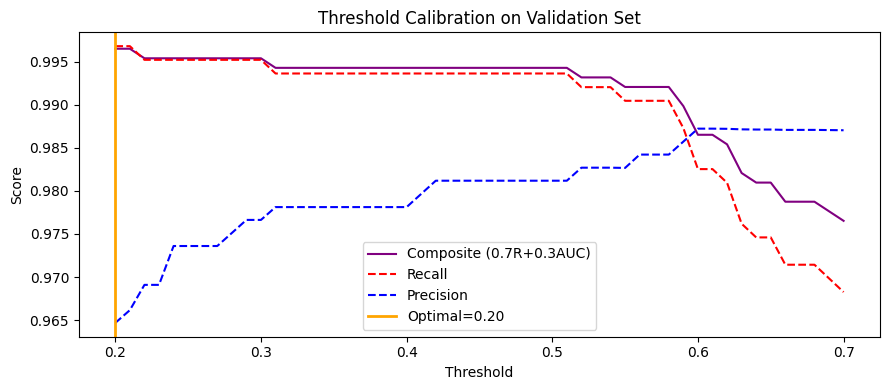

In [26]:
print("Loading best model for threshold calibration")
model = load_best_model(model, BEST_MODEL_PATH)

val_metrics_raw = evaluate(model, val_loader, criterion, threshold=0.5)
val_probs       = val_metrics_raw["probs"]

val_targets = np.concatenate([
    labels.cpu().numpy() for _, labels in val_loader
])

best_thresh, best_cs = 0.5, -np.inf
threshold_results = []

for thr in np.arange(0.20, 0.71, 0.01):
    preds_t = (val_probs >= thr).astype(int)
    try:
        m  = compute_metrics(val_probs, preds_t, val_targets, thr)
        cs = composite_score(m)
        threshold_results.append((thr, cs, m["recall"], m["precision"]))
        if cs > best_cs:
            best_cs, best_thresh = cs, thr
    except Exception:
        pass

OPTIMAL_THRESHOLD = best_thresh
print(f"\nOptimal threshold : {OPTIMAL_THRESHOLD:.2f}  (composite={best_cs:.4f})")

thrs, css, recs, precs = zip(*threshold_results)
plt.figure(figsize=(9, 4))
plt.plot(thrs, css,   label="Composite (0.7R+0.3AUC)", color="purple")
plt.plot(thrs, recs,  label="Recall",    linestyle="--", color="red")
plt.plot(thrs, precs, label="Precision", linestyle="--", color="blue")
plt.axvline(OPTIMAL_THRESHOLD, color="orange", linewidth=2,
            label=f"Optimal={OPTIMAL_THRESHOLD:.2f}")
plt.xlabel("Threshold"); plt.ylabel("Score")
plt.title("Threshold Calibration on Validation Set"); plt.legend()
plt.tight_layout(); plt.show()

### Final evaluation on TEST set

FINAL TEST EVALUATION  (threshold=0.20)
Best model loaded from /kaggle/working/best_brain_tumor_b3.pth



[TEST] Metrics  (threshold=0.20)
  Accuracy    : 0.9788
  Precision   : 0.9924
  Recall(Sen) : 0.9792  ← medical priority
  Specificity : 0.9775
  F1 Score    : 0.9857
  ROC-AUC     : 0.9965
  Composite   : 0.9844  (0.7×Recall + 0.3×AUC)

  Confusion Matrix:
              Pred 0    Pred 1
  True 0  :   TN=  391   FP=    9
  True 1  :   FN=   25   TP= 1175

Classification Report:
              precision    recall  f1-score   support

    No Tumor       0.94      0.98      0.96       400
       Tumor       0.99      0.98      0.99      1200

    accuracy                           0.98      1600
   macro avg       0.97      0.98      0.97      1600
weighted avg       0.98      0.98      0.98      1600



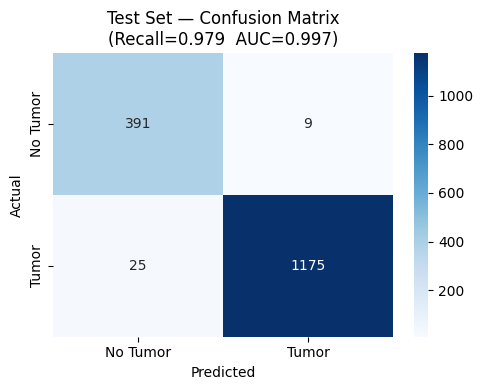

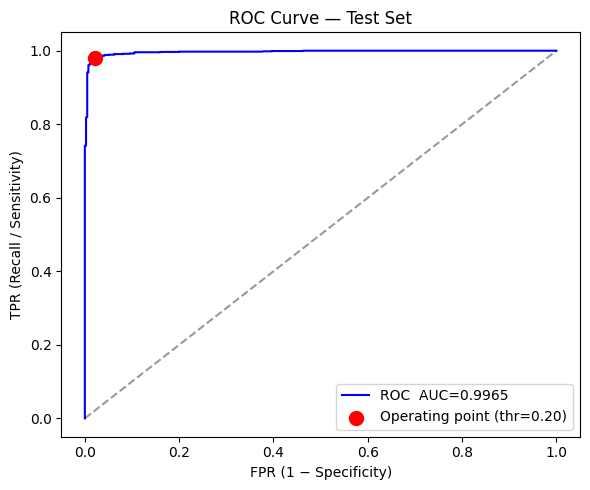

In [27]:
print(f"FINAL TEST EVALUATION  (threshold={OPTIMAL_THRESHOLD:.2f})")

model = load_best_model(model, BEST_MODEL_PATH)
test_metrics = evaluate(model, test_loader, criterion, threshold=OPTIMAL_THRESHOLD)
print_metrics(test_metrics, split="TEST")

test_probs   = test_metrics["probs"]
test_preds   = (test_probs >= OPTIMAL_THRESHOLD).astype(int)

test_targets = np.concatenate([
    labels.cpu().numpy() for _, labels in test_loader
])

print("\nClassification Report:")
print(classification_report(test_targets, test_preds,
                             target_names=BINARY_CLASS_NAMES))
plot_confusion_matrix(test_metrics, title="Test Set — Confusion Matrix")

fpr, tpr, _ = roc_curve(test_targets, test_probs)
plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, color="blue",
         label=f"ROC  AUC={test_metrics['roc_auc']:.4f}")
plt.plot([0, 1], [0, 1], "k--", alpha=0.4)
plt.scatter(1 - test_metrics["specificity"], test_metrics["recall"],
            color="red", s=100, zorder=5,
            label=f"Operating point (thr={OPTIMAL_THRESHOLD:.2f})")
plt.xlabel("FPR (1 − Specificity)"); plt.ylabel("TPR (Recall / Sensitivity)")
plt.title("ROC Curve — Test Set"); plt.legend()
plt.tight_layout(); plt.show()

### TTA evaluation on test set

TTA TEST EVALUATION 


TTA (5 views): 100%|██████████| 50/50 [01:48<00:00,  2.17s/it]


[TEST (TTA)] Metrics  (threshold=0.20)
  Accuracy    : 0.9819
  Precision   : 0.9941
  Recall(Sen) : 0.9817  ← medical priority
  Specificity : 0.9825
  F1 Score    : 0.9878
  ROC-AUC     : 0.9975
  Composite   : 0.9864  (0.7×Recall + 0.3×AUC)

  Confusion Matrix:
              Pred 0    Pred 1
  True 0  :   TN=  393   FP=    7
  True 1  :   FN=   22   TP= 1178


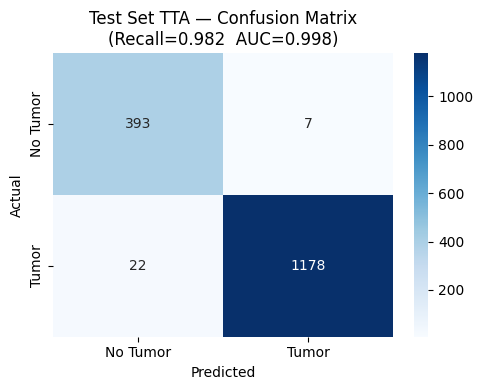


Standard vs TTA:
  accuracy    : std=0.9788  tta=0.9819  Δ=+0.0031
  recall      : std=0.9792  tta=0.9817  Δ=+0.0025
  precision   : std=0.9924  tta=0.9941  Δ=+0.0017
  f1          : std=0.9857  tta=0.9878  Δ=+0.0021
  roc_auc     : std=0.9965  tta=0.9975  Δ=+0.0010


In [28]:
print("TTA TEST EVALUATION ")

tta_probs, _, tta_targets = tta_predict(
    model, tta_test_loader, device, n_views=5, threshold=OPTIMAL_THRESHOLD
)
tta_preds   = (tta_probs >= OPTIMAL_THRESHOLD).astype(int)
tta_metrics = compute_metrics(tta_probs, tta_preds, tta_targets, OPTIMAL_THRESHOLD)
print_metrics(tta_metrics, split="TEST (TTA)")
plot_confusion_matrix(tta_metrics, title="Test Set TTA — Confusion Matrix")

print("\nStandard vs TTA:")
for key in ("accuracy", "recall", "precision", "f1", "roc_auc"):
    std   = test_metrics[key]
    tta   = tta_metrics[key]
    delta = tta - std
    print(f"  {key:12s}: std={std:.4f}  tta={tta:.4f}  Δ={delta:+.4f}")

### Grad-CAM

Best model loaded from /kaggle/working/best_brain_tumor_b3.pth


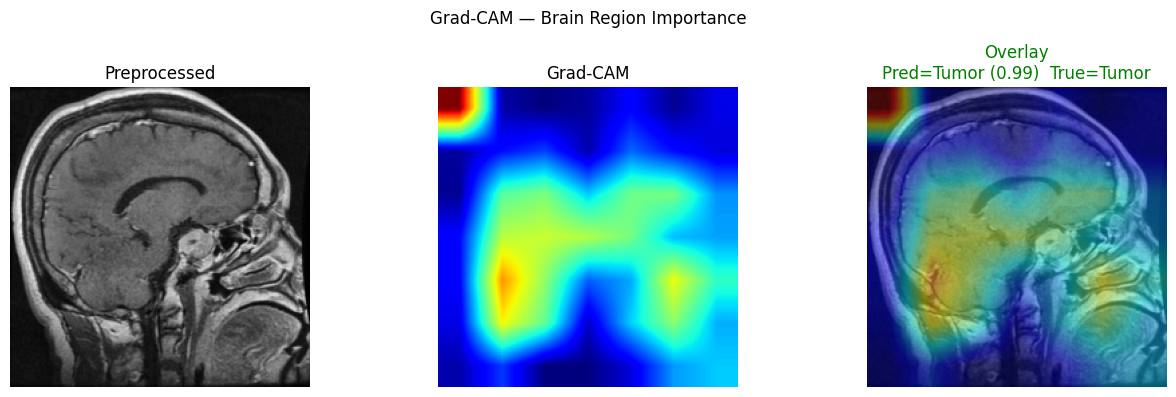

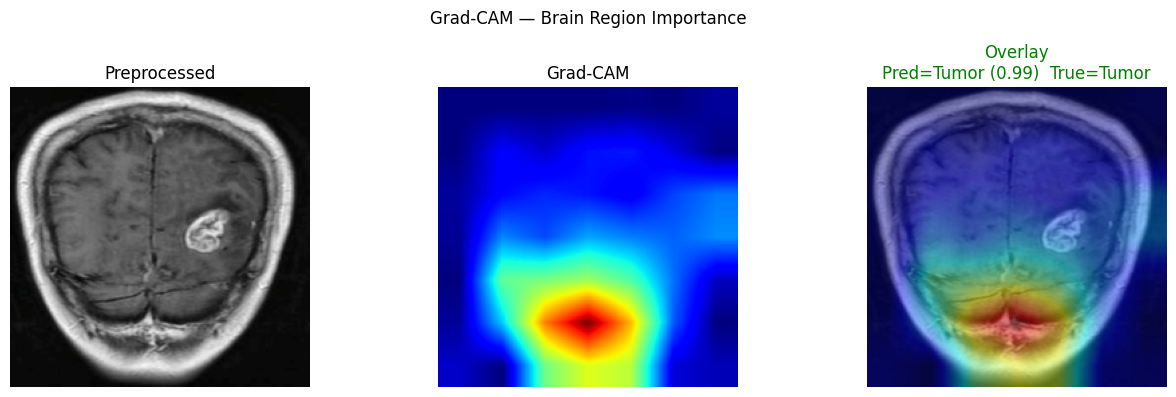

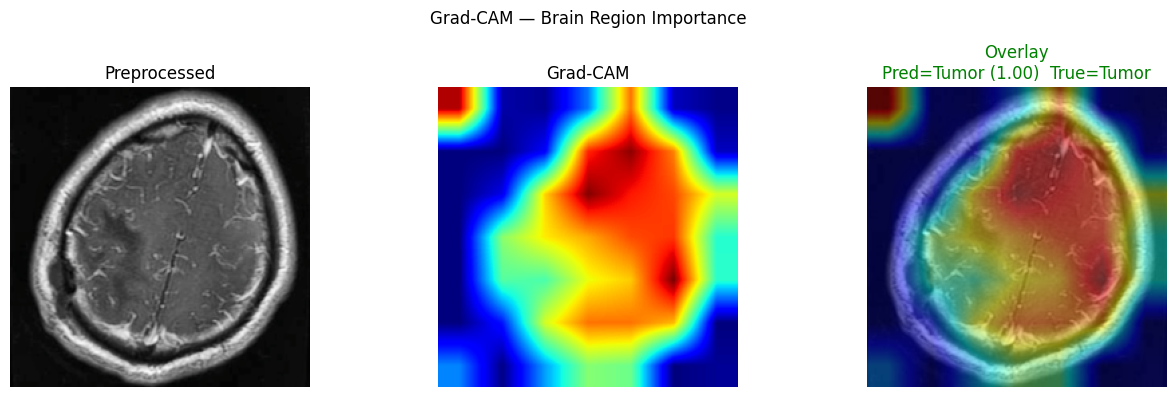

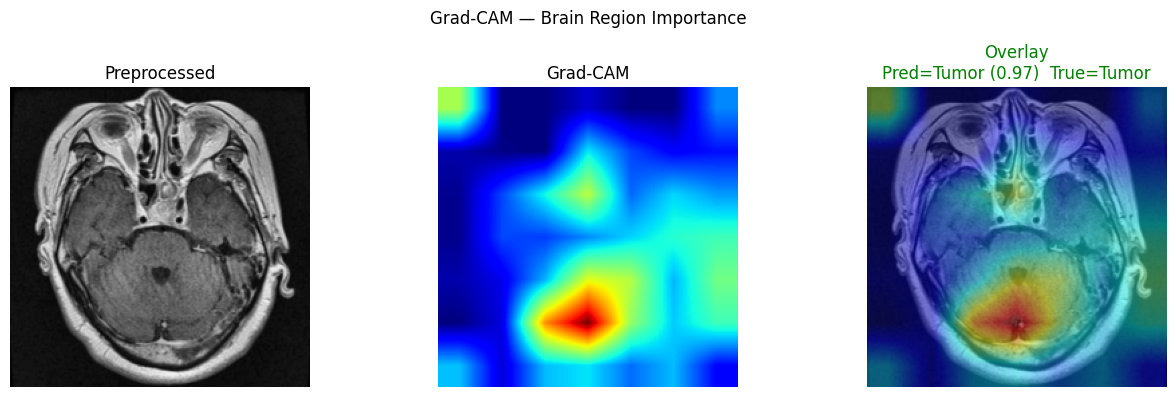

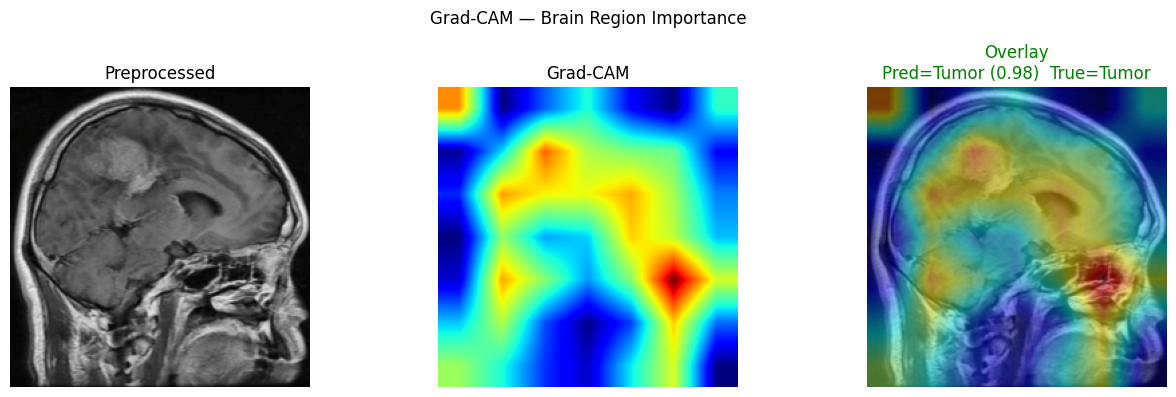

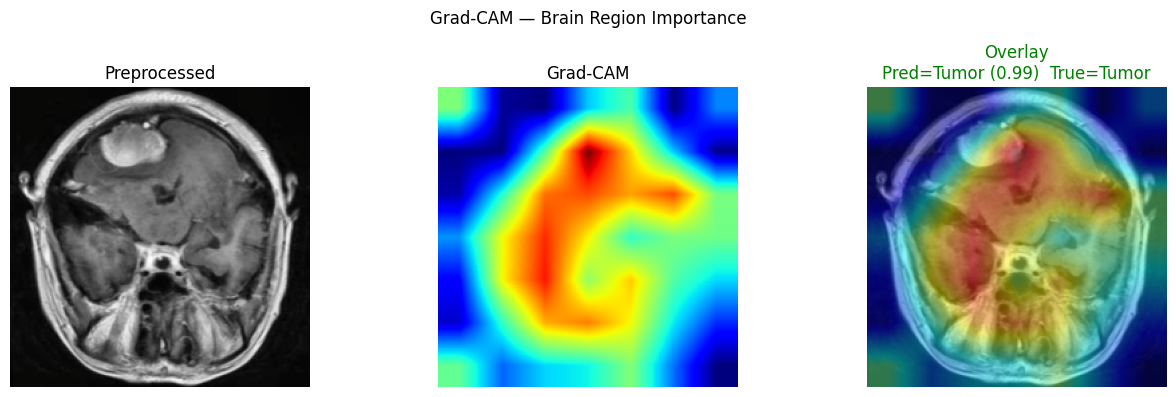

In [29]:
class GradCAM:
   
    def __init__(self, model: nn.Module, target_layer: nn.Module):
        self.model  = model
        self._grads = None
        self._acts  = None
        self._fh = target_layer.register_forward_hook(self._save_activations)
        self._bh = target_layer.register_full_backward_hook(self._save_gradients)

    def _save_activations(self, module, input, output):
        self._acts = output.detach()

    def _save_gradients(self, module, grad_input, grad_output):
        self._grads = grad_output[0].detach()

    def __call__(self, img_tensor: torch.Tensor) -> tuple:
       
        self.model.zero_grad()
        self.model.eval()

        logit = self.model(img_tensor).squeeze(1)   
        logit.backward()                             

        weights = self._grads.mean(dim=(2, 3), keepdim=True)   
        cam     = (weights * self._acts).sum(dim=1).squeeze()  
        cam     = F.relu(cam).cpu().numpy()
        cam     = (cam - cam.min()) / (cam.max() - cam.min() + 1e-8)
        return cam, logit.item()

    def remove_hooks(self):
        self._fh.remove()
        self._bh.remove()


def visualise_grad_cam(model, img_path: str, label: int,
                       threshold: float = OPTIMAL_THRESHOLD):
    raw, _     = load_and_crop(img_path)
    img_tensor = eval_transforms(raw).unsqueeze(0).to(device)

    gcam = GradCAM(model, target_layer=model.features[-1])

    with torch.enable_grad():
        cam, logit_val = gcam(img_tensor)   

    gcam.remove_hooks()

    cam_resized = cv2.resize(cam, (IMG_SIZE, IMG_SIZE))
    heat_map    = cv2.cvtColor(
        cv2.applyColorMap(np.uint8(255 * cam_resized), cv2.COLORMAP_JET),
        cv2.COLOR_BGR2RGB
    )

    img_np = img_tensor.squeeze(0).permute(1, 2, 0).cpu().numpy()
    img_np = np.clip(img_np * np.array(DATASET_STD) + np.array(DATASET_MEAN), 0, 1)
    overlay = np.clip(0.55 * img_np + 0.45 * heat_map / 255.0, 0, 1)

    # FIX 7: prob from the logit we already computed
    prob  = float(torch.sigmoid(torch.tensor(logit_val)).item())
    pred  = int(prob >= threshold)
    color = "green" if pred == label else "red"

    fig, axes = plt.subplots(1, 3, figsize=(13, 4))
    axes[0].imshow(img_np);         axes[0].set_title("Preprocessed"); axes[0].axis("off")
    axes[1].imshow(cam_resized, cmap="jet"); axes[1].set_title("Grad-CAM");      axes[1].axis("off")
    axes[2].imshow(overlay)
    axes[2].set_title(
        f"Overlay\nPred={BINARY_CLASS_NAMES[pred]} ({prob:.2f})  "
        f"True={BINARY_CLASS_NAMES[label]}", color=color
    )
    axes[2].axis("off")
    plt.suptitle("Grad-CAM — Brain Region Importance", fontsize=12)
    plt.tight_layout(); plt.show()


model = load_best_model(model, BEST_MODEL_PATH)
for idx in random.sample(range(len(test_paths)), min(6, len(test_paths))):
    visualise_grad_cam(model, test_paths[idx], test_labels[idx])

### Inference pipeline

In [30]:
def predict_single(model, img_path: str,
                   threshold: float = OPTIMAL_THRESHOLD,
                   n_tta_views: int = 5) -> dict:
   
    raw, crop_applied = load_and_crop(img_path)

    if n_tta_views > 1:
        tta_pipes = _tta_transforms(n_tta_views)
        probs_acc = 0.0
        model.eval()
        with torch.no_grad():
            for pipe in tta_pipes:
                tensor = pipe(raw).unsqueeze(0).to(device)
                with autocast(device_type=AMP_DEVICE):           
                    logit = model(tensor).squeeze(1)            
                probs_acc += torch.sigmoid(logit.float()).item()
        prob = probs_acc / n_tta_views
    else:
        tensor = eval_transforms(raw).unsqueeze(0).to(device)
        model.eval()
        with torch.no_grad():
            with autocast(device_type=AMP_DEVICE):               
                logit = model(tensor).squeeze(1)              
            prob = torch.sigmoid(logit.float()).item()

    pred       = int(prob >= threshold)
    label_name = BINARY_CLASS_NAMES[pred]
    confidence = prob if pred == 1 else 1.0 - prob

    return {
        "path"        : img_path,
        "probability" : round(prob, 4),
        "prediction"  : pred,
        "label_name"  : label_name,
        "confidence"  : round(confidence, 4),
        "crop_applied": crop_applied,
        "threshold"   : threshold,
    }


def predict_batch_from_folder(model, folder_path: str,
                               threshold: float = OPTIMAL_THRESHOLD,
                               n_tta_views: int = 5) -> list:
    """Run inference on all MRI images inside a folder."""
    valid_ext = (".jpg", ".jpeg", ".png", ".tif", ".tiff")
    img_files = [
        os.path.join(folder_path, f)
        for f in sorted(os.listdir(folder_path))
        if f.lower().endswith(valid_ext)
    ]
    results = []
    for path in tqdm(img_files, desc="Inference"):
        try:
            results.append(predict_single(model, path, threshold, n_tta_views))
        except Exception as e:
            results.append({"path": path, "error": str(e)})
    return results


# Demo
sample_result = predict_single(model, test_paths[0], n_tta_views=5)
print("\nSingle-image inference result:")
for k, v in sample_result.items():
    print(f"  {k:15s}: {v}")


Single-image inference result:
  path           : /kaggle/input/datasets/masoudnickparvar/brain-tumor-mri-dataset/Testing/glioma/Te-gl_1.jpg
  probability    : 0.7908
  prediction     : 1
  label_name     : Tumor
  confidence     : 0.7908
  crop_applied   : True
  threshold      : 0.2


### Export & load model

In [31]:
def export_model(model, metrics: dict,
                 export_path: str = f"{CHECKPOINT_DIR}/brain_tumor_b3_final.pth"):
   
    torch.save({
        "model_state_dict"  : model.state_dict(),
        "model_architecture": "EfficientNet-B3 binary classifier",
        "num_output"        : 1,
        "dataset_mean"      : DATASET_MEAN,
        "dataset_std"       : DATASET_STD,
        "img_size"          : IMG_SIZE,
        "optimal_threshold" : OPTIMAL_THRESHOLD,
        "binary_class_names": BINARY_CLASS_NAMES,
        "stage1_epochs"     : STAGE1_EPOCHS,
        "stage2_epochs"     : STAGE2_EPOCHS,
        "mixup_alpha"       : MIXUP_ALPHA,
        "label_smoothing"   : LABEL_SMOOTHING,
        "pos_weight_used"     : EFFECTIVE_POS_WEIGHT,   
        "pos_weight_dataset_ratio": POS_WEIGHT,       
        "seed"              : SEED,
        "test_metrics"      : {
            k: float(v) if isinstance(v, (np.floating, float)) else v
            for k, v in metrics.items()
            if k not in ("confusion", "probs")
        },
    }, export_path)
    print(f"Model exported → {export_path}")
    return export_path


def load_exported_model(export_path: str) -> tuple:
   
    ckpt  = torch.load(export_path, map_location=device, weights_only=False)
    m     = BrainTumorB3(dropout=0.4).to(device)
    m.load_state_dict(ckpt["model_state_dict"])
    m.eval()
    print(f"Model loaded from {export_path}")
    print(f"  Architecture : {ckpt['model_architecture']}")
    print(f"  Test AUC     : {ckpt['test_metrics'].get('roc_auc', 'N/A'):.4f}")
    print(f"  Threshold    : {ckpt['optimal_threshold']:.2f}")
    return m, ckpt


export_path     = export_model(model, test_metrics)
_model_rt, _meta = load_exported_model(export_path)
_rt_result       = predict_single(_model_rt, test_paths[0],
                                  threshold=_meta["optimal_threshold"])
print(f"\nRound-trip check: {_rt_result['label_name']}  (p={_rt_result['probability']})")

Model exported → /kaggle/working/brain_tumor_b3_final.pth
Model loaded from /kaggle/working/brain_tumor_b3_final.pth
  Architecture : EfficientNet-B3 binary classifier
  Test AUC     : 0.9965
  Threshold    : 0.20

Round-trip check: Tumor  (p=0.8045)


### Final summary

In [32]:
print("TRAINING COMPLET")

std_cs = composite_score(test_metrics)
tta_cs = composite_score(tta_metrics)

rows = [
    ("Architecture",        "EfficientNet-B3 (ImageNet pretrained)"),
    ("Task",                "Binary: Tumor (1) vs No Tumor (0)"),
    ("Input size",          f"{IMG_SIZE}×{IMG_SIZE} px"),
    ("Stage 1 epochs",      str(len(history_s1["train_loss"]))),
    ("Stage 2 epochs",      str(len(history_s2["train_loss"]))),
    ("Optimal threshold",   f"{OPTIMAL_THRESHOLD:.2f}"),
    ("───────────────────", ""),
    ("Test Accuracy",       f"{test_metrics['accuracy']:.4f}"),
    ("Test Recall (Sens.)", f"{test_metrics['recall']:.4f}"),
    ("Test Specificity",    f"{test_metrics['specificity']:.4f}"),
    ("Test Precision",      f"{test_metrics['precision']:.4f}"),
    ("Test F1",             f"{test_metrics['f1']:.4f}"),
    ("Test ROC-AUC",        f"{test_metrics['roc_auc']:.4f}"),
    ("Test Composite",      f"{std_cs:.4f}"),
    ("───────────────────", ""),
    ("TTA Recall (Sens.)",  f"{tta_metrics['recall']:.4f}"),
    ("TTA ROC-AUC",         f"{tta_metrics['roc_auc']:.4f}"),
    ("TTA Composite",       f"{tta_cs:.4f}"),
    ("───────────────────", ""),
    ("Best model path",     BEST_MODEL_PATH),
    ("Exported model",      export_path),
]

for k, v in rows:
    print(f"  {k:<26s}: {v}" if v else f"  {k}")

TRAINING COMPLET
  Architecture              : EfficientNet-B3 (ImageNet pretrained)
  Task                      : Binary: Tumor (1) vs No Tumor (0)
  Input size                : 224×224 px
  Stage 1 epochs            : 10
  Stage 2 epochs            : 19
  Optimal threshold         : 0.20
  ───────────────────
  Test Accuracy             : 0.9788
  Test Recall (Sens.)       : 0.9792
  Test Specificity          : 0.9775
  Test Precision            : 0.9924
  Test F1                   : 0.9857
  Test ROC-AUC              : 0.9965
  Test Composite            : 0.9844
  ───────────────────
  TTA Recall (Sens.)        : 0.9817
  TTA ROC-AUC               : 0.9975
  TTA Composite             : 0.9864
  ───────────────────
  Best model path           : /kaggle/working/best_brain_tumor_b3.pth
  Exported model            : /kaggle/working/brain_tumor_b3_final.pth


---
# Part 3 >> Export ALL Outputs 



In [33]:
import os, json, shutil, zipfile
import numpy as np

OUT_DIR = "/kaggle/working/outputs"
os.makedirs(OUT_DIR, exist_ok=True)
print(f"Output directory ready: {OUT_DIR}")


Output directory ready: /kaggle/working/outputs


### 3.1 — Build a JSON-safe metrics dictionary

In [34]:
def _json_safe(obj):
    if isinstance(obj, dict):
        return {k: _json_safe(v) for k, v in obj.items() if k != "probs"}
    if isinstance(obj, (list, tuple)):
        return [_json_safe(v) for v in obj]
    if isinstance(obj, np.ndarray):
        return obj.tolist()
    if isinstance(obj, (np.floating,)):
        return float(obj)
    if isinstance(obj, (np.integer,)):
        return int(obj)
    if isinstance(obj, (np.bool_,)):
        return bool(obj)
    return obj

metrics_summary = {
    "img_size": IMG_SIZE,
    "seed": SEED,
    "optimal_threshold": float(OPTIMAL_THRESHOLD),
    "stage1_epochs_run": len(history_s1["train_loss"]),
    "stage2_epochs_run": len(history_s2["train_loss"]),
    "history_stage1": _json_safe(history_s1),
    "history_stage2": _json_safe(history_s2),
    "validation_metrics_at_optimal_threshold": _json_safe(val_metrics_raw),
    "test_metrics_standard": _json_safe(test_metrics),
    "test_metrics_tta": _json_safe(tta_metrics),
    "test_vs_tta_delta": {
        k: float(tta_metrics[k] - test_metrics[k])
        for k in ("accuracy", "recall", "precision", "f1", "roc_auc")
    },
}

metrics_path = os.path.join(OUT_DIR, "metrics.json")
with open(metrics_path, "w") as f:
    json.dump(metrics_summary, f, indent=2)

print(f"Saved → {metrics_path}")


Saved → /kaggle/working/outputs/metrics.json


In [35]:
report_txt = classification_report(test_targets, test_preds, target_names=BINARY_CLASS_NAMES)
report_path = os.path.join(OUT_DIR, "classification_report.txt")
with open(report_path, "w") as f:
    f.write(f"FINAL TEST EVALUATION (threshold={OPTIMAL_THRESHOLD:.2f})\n\n")
    f.write(report_txt)
    f.write("\n\nTTA vs Standard:\n")
    for key in ("accuracy", "recall", "precision", "f1", "roc_auc"):
        f.write(f"  {key:12s}: std={test_metrics[key]:.4f}  tta={tta_metrics[key]:.4f}\n")

print(f"Saved → {report_path}")
print(report_txt)


Saved → /kaggle/working/outputs/classification_report.txt
              precision    recall  f1-score   support

    No Tumor       0.94      0.98      0.96       400
       Tumor       0.99      0.98      0.99      1200

    accuracy                           0.98      1600
   macro avg       0.97      0.98      0.97      1600
weighted avg       0.98      0.98      0.98      1600



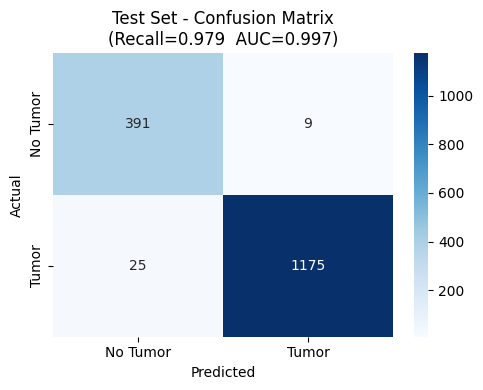

Saved -> /kaggle/working/outputs/confusion_matrix_test.png


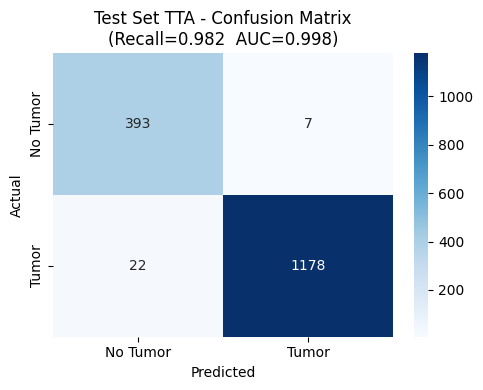

Saved -> /kaggle/working/outputs/confusion_matrix_tta.png


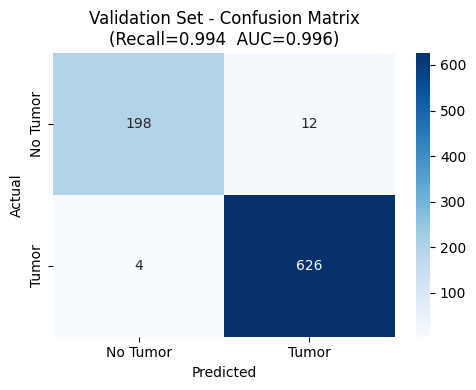

Saved -> /kaggle/working/outputs/confusion_matrix_val.png


In [36]:
def save_confusion_matrix(metrics, title, filename):
    cm = metrics["confusion"]
    fig, ax = plt.subplots(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax,
                xticklabels=BINARY_CLASS_NAMES, yticklabels=BINARY_CLASS_NAMES)
    ax.set_xlabel("Predicted"); ax.set_ylabel("Actual")
    r = metrics["recall"]; auc = metrics["roc_auc"]
    ax.set_title(f"{title}\n(Recall={r:.3f}  AUC={auc:.3f})")
    plt.tight_layout()
    path = os.path.join(OUT_DIR, filename)
    plt.savefig(path, dpi=150)
    plt.show()
    print(f"Saved -> {path}")

save_confusion_matrix(test_metrics, "Test Set - Confusion Matrix", "confusion_matrix_test.png")
save_confusion_matrix(tta_metrics, "Test Set TTA - Confusion Matrix", "confusion_matrix_tta.png")
save_confusion_matrix(val_metrics_raw, "Validation Set - Confusion Matrix", "confusion_matrix_val.png")


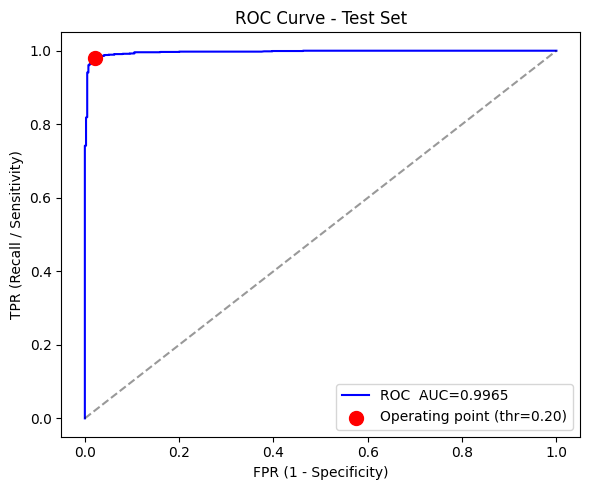

Saved -> /kaggle/working/outputs/roc_curve.png


In [37]:
fpr, tpr, _ = roc_curve(test_targets, test_probs)
auc_val = test_metrics["roc_auc"]
plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, color="blue", label=f"ROC  AUC={auc_val:.4f}")
plt.plot([0, 1], [0, 1], "k--", alpha=0.4)
plt.scatter(1 - test_metrics["specificity"], test_metrics["recall"],
            color="red", s=100, zorder=5,
            label=f"Operating point (thr={OPTIMAL_THRESHOLD:.2f})")
plt.xlabel("FPR (1 - Specificity)"); plt.ylabel("TPR (Recall / Sensitivity)")
plt.title("ROC Curve - Test Set"); plt.legend()
plt.tight_layout()
roc_path = os.path.join(OUT_DIR, "roc_curve.png")
plt.savefig(roc_path, dpi=150)
plt.show()
print(f"Saved -> {roc_path}")


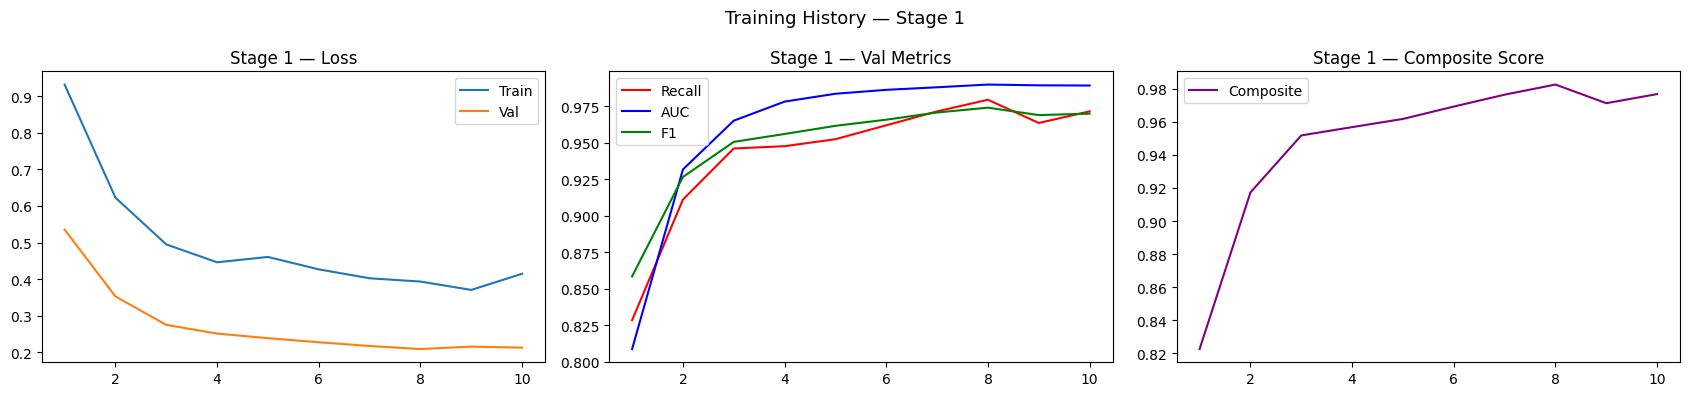

Saved → /kaggle/working/outputs/training_history_stage1.png


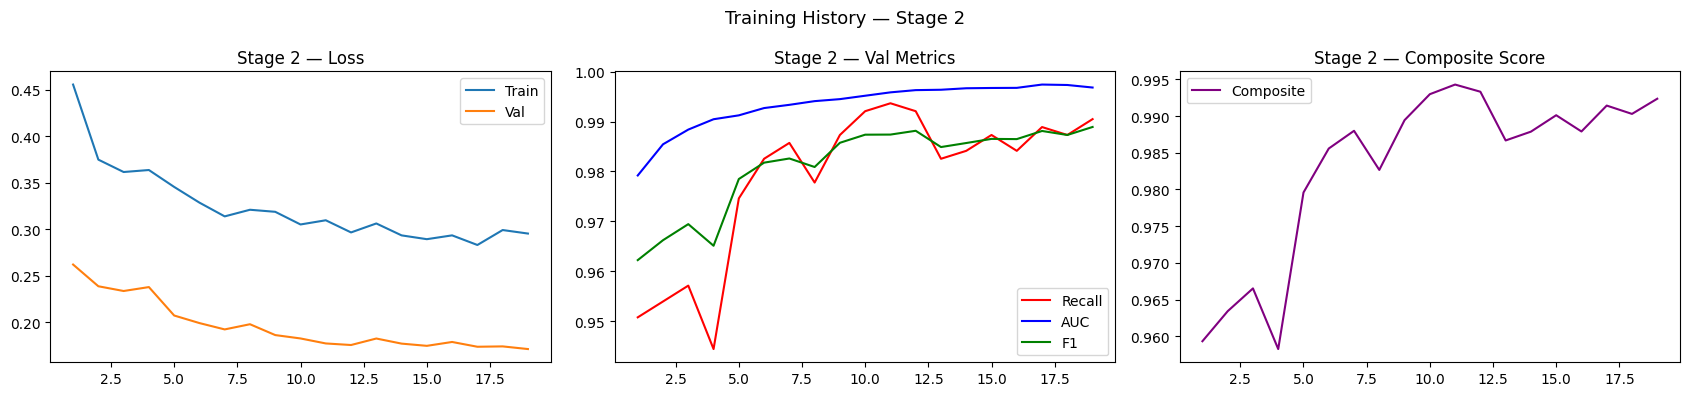

Saved → /kaggle/working/outputs/training_history_stage2.png


In [38]:
def save_history_plot(history, stage):
    epochs = range(1, len(history["train_loss"]) + 1)
    fig, axes = plt.subplots(1, 3, figsize=(17, 4))

    axes[0].plot(epochs, history["train_loss"], label="Train")
    axes[0].plot(epochs, history["val_loss"],   label="Val")
    axes[0].set_title(f"Stage {stage} — Loss"); axes[0].legend()

    axes[1].plot(epochs, history["val_recall"], label="Recall", color="red")
    axes[1].plot(epochs, history["val_auc"],    label="AUC",    color="blue")
    axes[1].plot(epochs, history["val_f1"],     label="F1",     color="green")
    axes[1].set_title(f"Stage {stage} — Val Metrics"); axes[1].legend()

    axes[2].plot(epochs, history["composite"],  label="Composite", color="purple")
    axes[2].set_title(f"Stage {stage} — Composite Score"); axes[2].legend()

    plt.suptitle(f"Training History — Stage {stage}", fontsize=13)
    plt.tight_layout()
    path = os.path.join(OUT_DIR, f"training_history_stage{stage}.png")
    plt.savefig(path, dpi=150)
    plt.show()
    print(f"Saved → {path}")

save_history_plot(history_s1, stage=1)
save_history_plot(history_s2, stage=2)


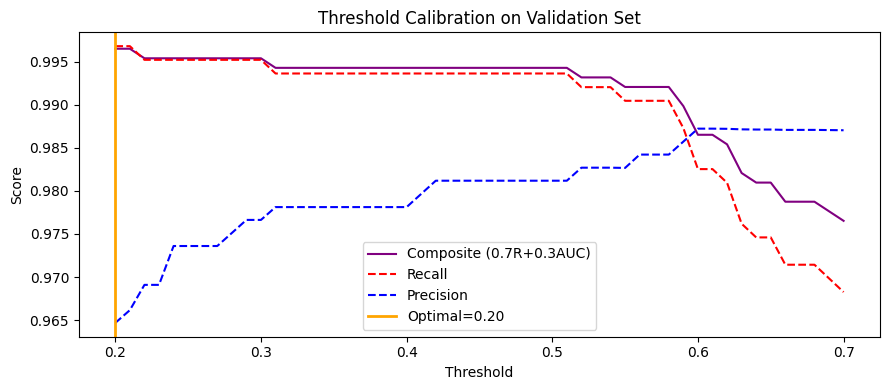

Saved → /kaggle/working/outputs/threshold_calibration.png


In [39]:
# Threshold calibration plot
thrs, css, recs, precs = zip(*threshold_results)
plt.figure(figsize=(9, 4))
plt.plot(thrs, css,   label="Composite (0.7R+0.3AUC)", color="purple")
plt.plot(thrs, recs,  label="Recall",    linestyle="--", color="red")
plt.plot(thrs, precs, label="Precision", linestyle="--", color="blue")
plt.axvline(OPTIMAL_THRESHOLD, color="orange", linewidth=2,
            label=f"Optimal={OPTIMAL_THRESHOLD:.2f}")
plt.xlabel("Threshold"); plt.ylabel("Score")
plt.title("Threshold Calibration on Validation Set"); plt.legend()
plt.tight_layout()
thr_path = os.path.join(OUT_DIR, "threshold_calibration.png")
plt.savefig(thr_path, dpi=150)
plt.show()
print(f"Saved → {thr_path}")


In [40]:
import csv

pred_csv_path = os.path.join(OUT_DIR, "test_predictions.csv")
with open(pred_csv_path, "w", newline="") as f:
    writer = csv.writer(f)
    writer.writerow(["image_path", "true_label", "true_label_name",
                      "predicted_probability", "predicted_label", "predicted_label_name",
                      "correct"])
    for path, true_lbl, prob, pred_lbl in zip(test_paths, test_targets, test_probs, test_preds):
        writer.writerow([
            path, int(true_lbl), BINARY_CLASS_NAMES[int(true_lbl)],
            round(float(prob), 4), int(pred_lbl), BINARY_CLASS_NAMES[int(pred_lbl)],
            int(true_lbl) == int(pred_lbl),
        ])

print(f"Saved → {pred_csv_path}  ({len(test_paths)} rows)")


Saved → /kaggle/working/outputs/test_predictions.csv  (1600 rows)


In [41]:
import h5py

for src in [BEST_MODEL_PATH, export_path]:
    if os.path.exists(src):
        dst = os.path.join(OUT_DIR, os.path.basename(src))
        shutil.copy2(src, dst)
        print(f"Copied → {dst}")

# Export an HDF5 (.h5) version of the final model weights + metadata
h5_path = os.path.join(OUT_DIR, "brain_tumor_b3_final.h5")
state_dict = model.state_dict()

with h5py.File(h5_path, "w") as hf:
    weights_grp = hf.create_group("model_weights")
    for name, tensor in state_dict.items():
        # HDF5 group/dataset names can't contain "/", PyTorch param names use "." so this is safe
        weights_grp.create_dataset(name, data=tensor.detach().cpu().numpy())

    cfg = hf.create_group("config")
    cfg.attrs["model_architecture"] = "EfficientNet-B3 binary classifier"
    cfg.attrs["num_output"] = 1
    cfg.attrs["img_size"] = IMG_SIZE
    cfg.attrs["dataset_mean"] = DATASET_MEAN
    cfg.attrs["dataset_std"] = DATASET_STD
    cfg.attrs["optimal_threshold"] = float(OPTIMAL_THRESHOLD)
    cfg.attrs["binary_class_names"] = BINARY_CLASS_NAMES
    cfg.attrs["seed"] = SEED
    cfg.attrs["test_accuracy"] = float(test_metrics["accuracy"])
    cfg.attrs["test_recall"] = float(test_metrics["recall"])
    cfg.attrs["test_roc_auc"] = float(test_metrics["roc_auc"])

print(f"Saved → {h5_path}")

with h5py.File(h5_path, "r") as hf:
    n_params = len(hf["model_weights"].keys())
    print(f"Verified: {n_params} weight tensors readable back from {h5_path}")


Copied → /kaggle/working/outputs/best_brain_tumor_b3.pth
Copied → /kaggle/working/outputs/brain_tumor_b3_final.pth
Saved → /kaggle/working/outputs/brain_tumor_b3_final.h5
Verified: 579 weight tensors readable back from /kaggle/working/outputs/brain_tumor_b3_final.h5


In [42]:
zip_path = "/kaggle/working/outputs.zip"
with zipfile.ZipFile(zip_path, "w", zipfile.ZIP_DEFLATED) as zf:
    for root, _, files in os.walk(OUT_DIR):
        for fname in files:
            full = os.path.join(root, fname)
            arcname = os.path.relpath(full, OUT_DIR)
            zf.write(full, arcname)

print(f"All outputs zipped → {zip_path}\n")
print("Files included in /kaggle/working/outputs:")
for fname in sorted(os.listdir(OUT_DIR)):
    size_kb = os.path.getsize(os.path.join(OUT_DIR, fname)) / 1024
    print(f"  {fname:35s} {size_kb:>10.1f} KB")




All outputs zipped → /kaggle/working/outputs.zip

Files included in /kaggle/working/outputs:
  best_brain_tumor_b3.pth                42362.8 KB
  brain_tumor_b3_final.h5                42393.5 KB
  brain_tumor_b3_final.pth               42364.4 KB
  classification_report.txt                  0.6 KB
  confusion_matrix_test.png                 34.8 KB
  confusion_matrix_tta.png                  36.5 KB
  confusion_matrix_val.png                  37.8 KB
  metrics.json                               6.2 KB
  roc_curve.png                             50.6 KB
  test_predictions.csv                     196.0 KB
  threshold_calibration.png                 65.3 KB
  training_history_stage1.png              115.2 KB
  training_history_stage2.png              131.4 KB
